In [1]:
import numpy as np
import pandas as pd
import neurokit2 as nk
import pywt
import pickle

from scipy.signal import butter, filtfilt, welch
from scipy.stats import entropy

In [2]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype='band'
    )

    filtered = filtfilt(
        b,
        a,
        signal
    )

    return filtered


In [3]:
def wavelet_denoise(signal,
                    wavelet='db4',
                    level=6):

    coeffs = pywt.wavedec(
        signal,
        wavelet,
        level=level
    )

    sigma = np.median(
        np.abs(coeffs[-1])
    ) / 0.6745

    threshold = sigma * np.sqrt(
        2 * np.log(len(signal))
    )

    coeffs[1:] = [
        pywt.threshold(
            c,
            threshold,
            mode='soft'
        )
        for c in coeffs[1:]
    ]

    denoised = pywt.waverec(
        coeffs,
        wavelet
    )

    return denoised[:len(signal)]


In [4]:
subjects = [
    'S2','S3','S4','S5',
    'S6','S7','S8','S9',
    'S10','S11','S13',
    'S14','S15','S16','S17'
]

print("Total Subjects:", len(subjects))

Total Subjects: 15


In [5]:
def load_subject(subject):

    file_path = f"../data/WESAD/{subject}/{subject}.pkl"

    with open(file_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    ecg = data['signal']['chest']['ECG'].flatten()
    ppg = data['signal']['wrist']['BVP'].flatten()
    eda = data['signal']['wrist']['EDA'].flatten()
    labels = data['label'].flatten()

    return ecg, ppg, eda, labels

In [6]:
ecg, ppg, eda, labels = load_subject("S2")

print("ECG:", ecg.shape)
print("PPG:", ppg.shape)
print("EDA:", eda.shape)
print("Labels:", labels.shape)

ECG: (4255300,)
PPG: (389056,)
EDA: (24316,)
Labels: (4255300,)


In [7]:
def preprocess_subject(ecg, ppg, eda):

    # ECG
    ecg_filtered = bandpass_filter(
        ecg,
        lowcut=0.5,
        highcut=40,
        fs=700
    )

    ecg_denoised = wavelet_denoise(ecg_filtered)

    # PPG
    ppg_filtered = bandpass_filter(
        ppg,
        lowcut=0.5,
        highcut=8,
        fs=64
    )

    ppg_denoised = wavelet_denoise(ppg_filtered)

    # EDA
    signals, info = nk.eda_process(
        eda,
        sampling_rate=4
    )

    eda_clean = signals["EDA_Clean"]
    tonic = signals["EDA_Tonic"]
    phasic = signals["EDA_Phasic"]

    return (
        ecg_denoised,
        ppg_denoised,
        eda_clean,
        tonic,
        phasic
    )

In [8]:
ecg_p, ppg_p, eda_p, tonic, phasic = preprocess_subject(
    ecg,
    ppg,
    eda
)

print("ECG:", len(ecg_p))
print("PPG:", len(ppg_p))
print("EDA:", len(eda_p))
print("Tonic:", len(tonic))
print("Phasic:", len(phasic))

ECG: 4255300
PPG: 389056
EDA: 24316
Tonic: 24316
Phasic: 24316


c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(


In [9]:
def get_valid_segments(labels):

    segments = []

    start = 0
    current_label = labels[0]

    for i in range(1, len(labels)):

        if labels[i] != current_label:

            segments.append(
                (current_label, start, i - 1)
            )

            start = i
            current_label = labels[i]

    segments.append(
        (
            current_label,
            start,
            len(labels) - 1
        )
    )

    valid_segments = []

    for label, start, end in segments:

        if label in [1, 2, 3]:

            valid_segments.append(
                (label, start, end)
            )

    return valid_segments

In [10]:
segments = get_valid_segments(labels)

print("Valid Segments:", len(segments))

for seg in segments[:5]:
    print(seg)

Valid Segments: 3
(np.int32(1), 214583, 1015382)
(np.int32(2), 1591482, 2021981)
(np.int32(3), 3334483, 3587882)


In [11]:
for label, start, end in segments:

    duration_sec = (end - start + 1) / 700

    print(
        f"Label {label}: "
        f"{duration_sec:.2f} sec "
        f"({duration_sec/60:.2f} min)"
    )

Label 1: 1144.00 sec (19.07 min)
Label 2: 615.00 sec (10.25 min)
Label 3: 362.00 sec (6.03 min)


In [12]:
def create_windows(
    ecg_signal,
    ppg_signal,
    eda_signal,
    valid_segments
):

    WINDOW_SEC = 60

    FS_ECG = 700
    FS_PPG = 64
    FS_EDA = 4

    ECG_WIN = WINDOW_SEC * FS_ECG
    PPG_WIN = WINDOW_SEC * FS_PPG
    EDA_WIN = WINDOW_SEC * FS_EDA

    ecg_windows = []
    ppg_windows = []
    eda_windows = []
    window_labels = []

    for label, start, end in valid_segments:

        segment_length = end - start + 1

        n_windows = segment_length // ECG_WIN

        for w in range(n_windows):

            ecg_start = start + w * ECG_WIN
            ecg_end = ecg_start + ECG_WIN

            ppg_start = int(ecg_start * FS_PPG / FS_ECG)
            ppg_end = ppg_start + PPG_WIN

            eda_start = int(ecg_start * FS_EDA / FS_ECG)
            eda_end = eda_start + EDA_WIN

            ecg_seg = ecg_signal[
                ecg_start:ecg_end
            ]

            ppg_seg = ppg_signal[
                ppg_start:ppg_end
            ]

            eda_seg = eda_signal[
                eda_start:eda_end
            ]

            if (
                len(ecg_seg) == ECG_WIN and
                len(ppg_seg) == PPG_WIN and
                len(eda_seg) == EDA_WIN
            ):

                ecg_windows.append(ecg_seg)
                ppg_windows.append(ppg_seg)
                eda_windows.append(eda_seg)

                window_labels.append(label)

    return (
        ecg_windows,
        ppg_windows,
        eda_windows,
        window_labels
    )

In [13]:
ecg_windows, ppg_windows, eda_windows, window_labels = create_windows(
    ecg_p,
    ppg_p,
    eda_p,
    segments
)

print("ECG Windows:", len(ecg_windows))
print("PPG Windows:", len(ppg_windows))
print("EDA Windows:", len(eda_windows))
print("Labels:", len(window_labels))

ECG Windows: 35
PPG Windows: 35
EDA Windows: 35
Labels: 35


In [14]:
ecg_windows = np.array(ecg_windows)
ppg_windows = np.array(ppg_windows)
eda_windows = np.array(eda_windows)

In [15]:
print(ecg_windows.shape)
print(ppg_windows.shape)
print(eda_windows.shape)

(35, 42000)
(35, 3840)
(35, 240)


In [16]:
ecg_window = ecg_windows[0]

In [17]:
print(type(ecg_window))
print(len(ecg_window))

<class 'numpy.ndarray'>
42000


In [18]:
import pywt

max_level = pywt.swt_max_level(len(ecg_window))

print("Max SWT Level =", max_level)

Max SWT Level = 4


In [19]:
ecg_window = ecg_windows[0]

print(type(ecg_window))
print(len(ecg_window))

<class 'numpy.ndarray'>
42000


In [20]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal,
                    lowcut=0.5,
                    highcut=40,
                    fs=700,
                    order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype='band'
    )

    filtered = filtfilt(
        b,
        a,
        signal
    )

    return filtered

In [21]:
ecg_filtered = bandpass_filter(ecg_window)

print(ecg_filtered.shape)

(42000,)


In [22]:
import numpy as np

def shannon_entropy(signal):

    hist, _ = np.histogram(
        signal,
        bins=50,
        density=True
    )

    hist = hist + 1e-12

    prob = hist / np.sum(hist)

    entropy_value = -np.sum(
        prob * np.log2(prob)
    )

    return entropy_value

In [23]:
print(
    shannon_entropy(
        ecg_filtered
    )
)

4.213872302884068


In [24]:
import pywt

def swt_denoise(signal,
                wavelet='db4',
                level=4):

    coeffs = pywt.swt(
        signal,
        wavelet,
        level=level
    )

    denoised_coeffs = []

    for approx, detail in coeffs:

        sigma = (
            np.median(
                np.abs(detail)
            )
            /
            0.6745
        )

        entropy_val = shannon_entropy(
            detail
        )

        threshold = (

            sigma

            *

            np.sqrt(
                2*np.log(
                    len(detail)
                )
            )

            *

            (
                1 +
                entropy_val/10
            )
        )

        detail_thresh = pywt.threshold(
            detail,
            threshold,
            mode='soft'
        )

        denoised_coeffs.append(
            (
                approx,
                detail_thresh
            )
        )

    reconstructed = pywt.iswt(
        denoised_coeffs,
        wavelet
    )

    return reconstructed

In [25]:
ecg_swt = swt_denoise(
    ecg_filtered
)

print(ecg_swt.shape)

(42000,)


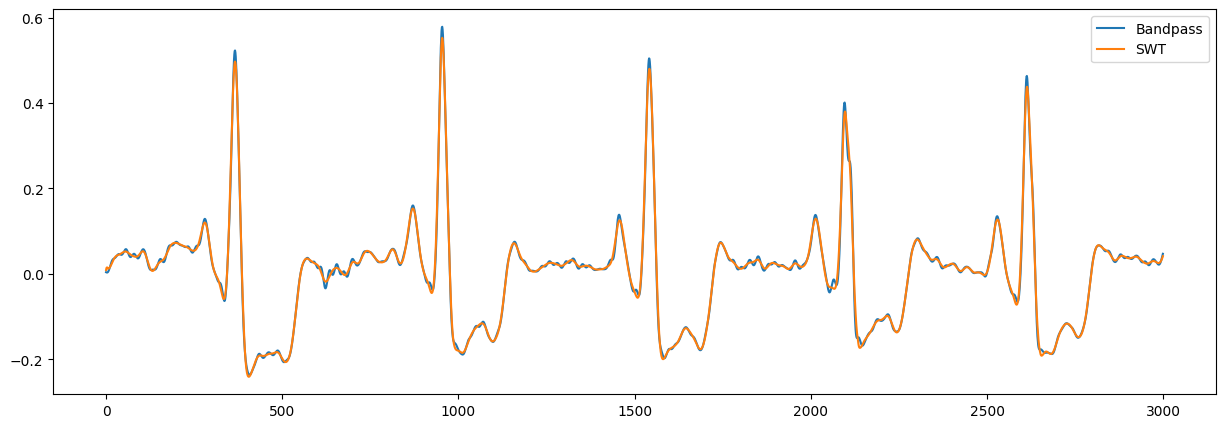

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    ecg_filtered[:3000],
    label="Bandpass"
)

plt.plot(
    ecg_swt[:3000],
    label="SWT"
)

plt.legend()

plt.show()

In [27]:
import neurokit2 as nk

signals, info = nk.ecg_process(
    ecg_swt,
    sampling_rate=700
)

r_peaks = info[
    "ECG_R_Peaks"
]

print(
    len(r_peaks)
)

81


In [28]:
rr = np.diff(r_peaks) / 700

print(rr[:10])
print(len(rr))

[0.84       0.84       0.79571429 0.73571429 0.71       0.67857143
 0.69285714 0.65142857 0.63285714 0.65142857]
80


In [29]:
mean_rr = np.mean(rr)

std_rr = np.std(rr)

rmssd = np.sqrt(
    np.mean(
        np.diff(rr)**2
    )
)

heart_rate = 60 / mean_rr

print(mean_rr)
print(std_rr)
print(rmssd)
print(heart_rate)

0.7428035714285715
0.09570880681280387
0.06542036636092166
80.77505589345385


In [30]:
import antropy as ant

In [31]:
sample_entropy = ant.sample_entropy(rr)

print(sample_entropy)

1.0655514264072217


In [32]:
rr1 = rr[:-1]

rr2 = rr[1:]

In [33]:
sd1 = np.sqrt(
    np.var(
        rr2 - rr1
    ) / 2
)

In [34]:
sd2 = np.sqrt(
    2*np.var(rr)
    -
    sd1**2
)

In [35]:
sd1_sd2 = sd1/(sd2+1e-8)

print(sd1)
print(sd2)
print(sd1_sd2)

0.04624006642855206
0.12720930649816592
0.3634959113173031


In [36]:
from scipy.signal import welch

In [37]:
freqs, psd = welch(
    rr,
    fs=4
)

C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\1835659236.py:1: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 80, using nperseg = 80
  freqs, psd = welch(


In [38]:
lf_band = (

    (freqs >= 0.04)

    &

    (freqs < 0.15)

)

hf_band = (

    (freqs >= 0.15)

    &

    (freqs < 0.40)

)

In [39]:
lf_power = np.trapezoid(
    psd[lf_band]
)

hf_power = np.trapezoid(
    psd[hf_band]
)

In [40]:
lf_hf_ratio = (
    lf_power
    /
    (hf_power + 1e-8)
)

print(lf_hf_ratio)

0.03685533156858316


In [41]:
ecg_features = {

    "mean_rr": mean_rr,

    "std_rr": std_rr,

    "rmssd": rmssd,

    "heart_rate": heart_rate,

    "sample_entropy": sample_entropy,

    "sd1": sd1,

    "sd2": sd2,

    "sd1_sd2": sd1_sd2,

    "lf_power": lf_power,

    "hf_power": hf_power,

    "lf_hf_ratio": lf_hf_ratio
}

In [42]:
for k,v in ecg_features.items():
    print(k,":",v)

mean_rr : 0.7428035714285715
std_rr : 0.09570880681280387
rmssd : 0.06542036636092166
heart_rate : 80.77505589345385
sample_entropy : 1.0655514264072217
sd1 : 0.04624006642855206
sd2 : 0.12720930649816592
sd1_sd2 : 0.3634959113173031
lf_power : 0.004344037925740966
hf_power : 0.11786727651883801
lf_hf_ratio : 0.03685533156858316


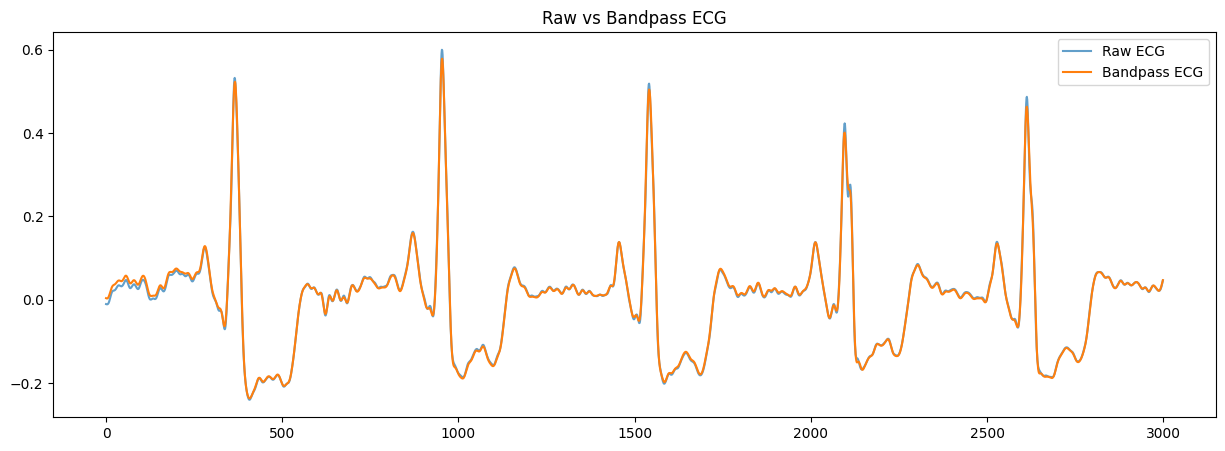

In [43]:
plt.figure(figsize=(15,5))

plt.plot(
    ecg_window[:3000],
    label="Raw ECG",
    alpha=0.7
)

plt.plot(
    ecg_filtered[:3000],
    label="Bandpass ECG"
)

plt.legend()
plt.title("Raw vs Bandpass ECG")
plt.show()

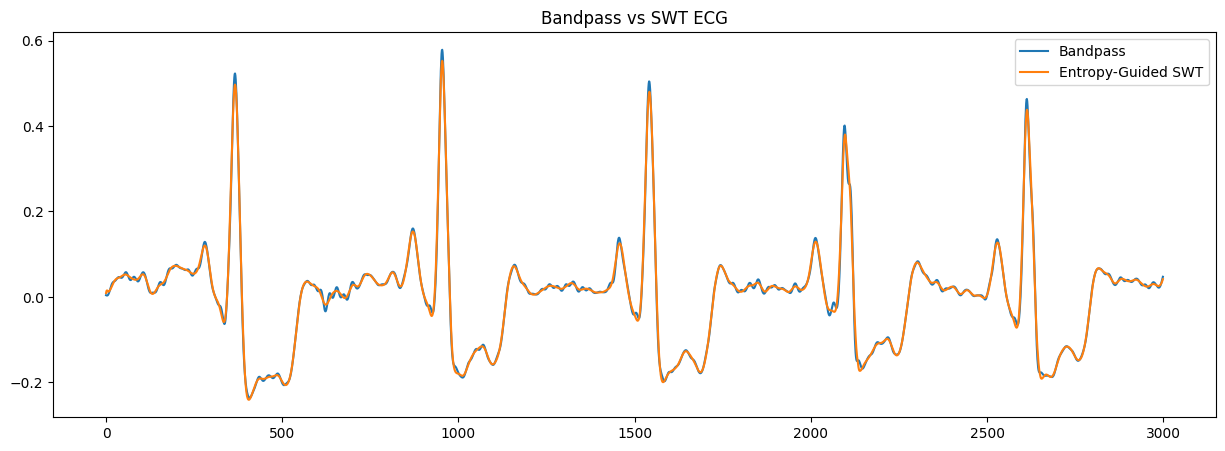

In [44]:
plt.figure(figsize=(15,5))

plt.plot(
    ecg_filtered[:3000],
    label="Bandpass"
)

plt.plot(
    ecg_swt[:3000],
    label="Entropy-Guided SWT"
)

plt.legend()
plt.title("Bandpass vs SWT ECG")
plt.show()

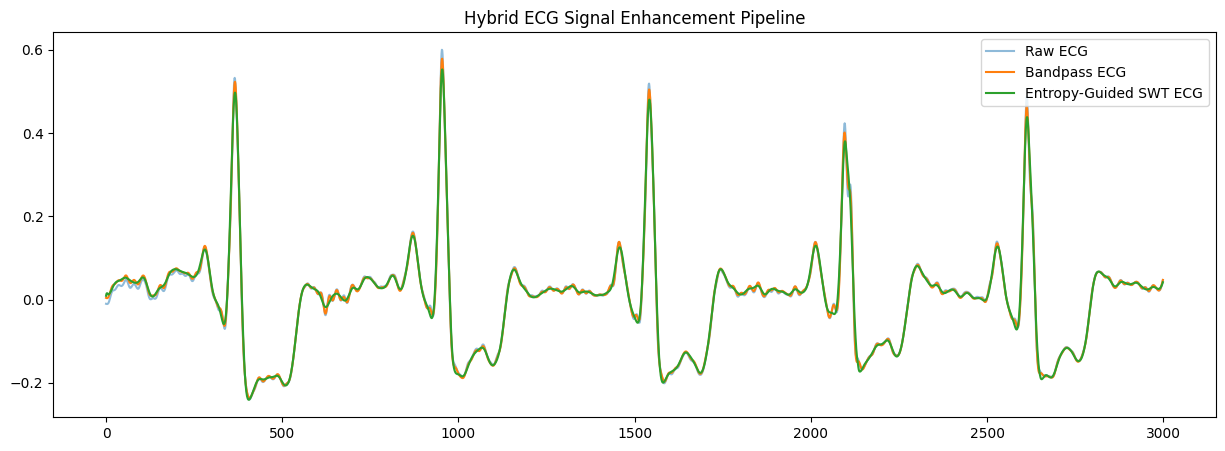

In [45]:
plt.figure(figsize=(15,5))

plt.plot(
    ecg_window[:3000],
    label="Raw ECG",
    alpha=0.5
)

plt.plot(
    ecg_filtered[:3000],
    label="Bandpass ECG"
)

plt.plot(
    ecg_swt[:3000],
    label="Entropy-Guided SWT ECG"
)

plt.legend()
plt.title(
    "Hybrid ECG Signal Enhancement Pipeline"
)

plt.show()

In [46]:
noise_before = ecg_window - ecg_filtered

noise_after = ecg_filtered - ecg_swt

snr_before = np.var(ecg_filtered) / np.var(noise_before)

snr_after = np.var(ecg_swt) / np.var(noise_after)

print("SNR Before:", snr_before)
print("SNR After:", snr_after)

SNR Before: 549.8477404636301
SNR After: 205.75956532888168


In [47]:
ppg_window = ppg_windows[0]

print(type(ppg_window))
print(len(ppg_window))

<class 'numpy.ndarray'>
3840


In [48]:
ppg_filtered = bandpass_filter(
    ppg_window,
    lowcut=0.5,
    highcut=8,
    fs=64
)

print(ppg_filtered.shape)

(3840,)


In [49]:
from scipy.ndimage import grey_opening
from scipy.ndimage import grey_closing

In [50]:
def morphology_filter(signal):

    opened = grey_opening(
        signal,
        size=5
    )

    closed = grey_closing(
        opened,
        size=5
    )

    return closed

In [51]:
ppg_morph = morphology_filter(
    ppg_filtered
)

print(ppg_morph.shape)

(3840,)


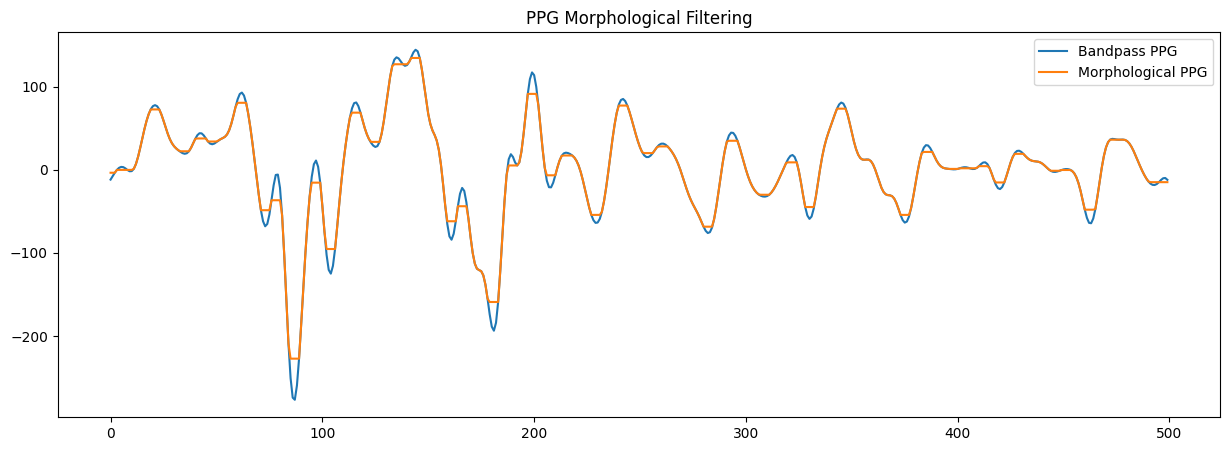

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    ppg_filtered[:500],
    label="Bandpass PPG"
)

plt.plot(
    ppg_morph[:500],
    label="Morphological PPG"
)

plt.legend()

plt.title(   "PPG Morphological Filtering"
)

plt.show()

In [53]:
import neurokit2 as nk

signals, info = nk.ppg_process(
    ppg_morph,
    sampling_rate=64
)

peaks = info["PPG_Peaks"]

print(len(peaks))

80


In [54]:
ibi = np.diff(peaks) / 64

print(len(ibi))
print(ibi[:10])

79
[0.640625 0.828125 0.453125 0.859375 0.671875 0.796875 0.8125   0.625
 0.6875   0.6875  ]


In [55]:
median_ibi = np.median(ibi)

print(median_ibi)

0.75


In [56]:
valid_mask = (

    (ibi > 0.5 * median_ibi)

    &

    (ibi < 1.5 * median_ibi)

)

ibi_refined = ibi[valid_mask]

print(len(ibi_refined))

68


In [57]:
print(
    len(ibi),
    len(ibi_refined)
)

79 68


In [58]:
mean_ibi = np.mean(
    ibi_refined
)

In [59]:
std_ibi = np.std(
    ibi_refined
)

In [60]:
pulse_rate = (
    60
    /
    mean_ibi
)

In [61]:
pulse_var = np.var(
    ibi_refined
)

In [62]:
print(mean_ibi)
print(std_ibi)
print(pulse_rate)
print(pulse_var)

0.7309283088235294
0.18311833369237576
82.0873939012889
0.033532324134272276


In [63]:
import antropy as ant

In [64]:
ppg_sample_entropy = ant.sample_entropy(
    ibi_refined
)

print(
    ppg_sample_entropy
)

2.1102132003465894


In [65]:
from scipy.signal import welch
from scipy.stats import entropy

In [66]:
freqs, psd = welch(
    ppg_morph,
    fs=64
)

In [67]:
psd_norm = psd / np.sum(psd)

spectral_entropy = entropy(
    psd_norm
)

print(
    spectral_entropy
)

2.3196458183871695


In [68]:
pulse_widths = []

for i in range(
    len(peaks)-1
):

    width = (

        peaks[i+1]

        -

        peaks[i]

    ) / 64

    pulse_widths.append(
        width
    )

In [69]:
pulse_width_mean = np.mean(
    pulse_widths
)

pulse_width_std = np.std(
    pulse_widths
)

print(
    pulse_width_mean
)

print(
    pulse_width_std
)

0.7444620253164557
0.24079470084837332


In [70]:
ppg_features = {

    "mean_ibi":
        mean_ibi,

    "std_ibi":
        std_ibi,

    "pulse_rate":
        pulse_rate,

    "pulse_var":
        pulse_var,

    "sample_entropy":
        ppg_sample_entropy,

    "spectral_entropy":
        spectral_entropy,

    "pulse_width_mean":
        pulse_width_mean,

    "pulse_width_std":
        pulse_width_std
}

In [71]:
for k,v in ppg_features.items():

    print(
        k,
        ":",
        v
    )

mean_ibi : 0.7309283088235294
std_ibi : 0.18311833369237576
pulse_rate : 82.0873939012889
pulse_var : 0.033532324134272276
sample_entropy : 2.1102132003465894
spectral_entropy : 2.3196458183871695
pulse_width_mean : 0.7444620253164557
pulse_width_std : 0.24079470084837332


In [72]:
import antropy as ant

hfd = ant.higuchi_fd(
    ppg_morph
)

print(
    "Higuchi FD:",
    hfd
)

Higuchi FD: 1.0482939177451611


In [73]:
dfa = ant.detrended_fluctuation(
    ppg_morph
)

print(
    "DFA:",
    dfa
)

DFA: 1.0300081785970494


In [74]:
def hjorth_parameters(signal):

    first_deriv = np.diff(signal)

    second_deriv = np.diff(
        first_deriv
    )

    activity = np.var(signal)

    mobility = np.sqrt(
        np.var(first_deriv)
        /
        activity
    )

    complexity = np.sqrt(
        np.var(second_deriv)
        /
        np.var(first_deriv)
    ) / mobility

    return (
        activity,
        mobility,
        complexity
    )

In [75]:
activity,\
mobility,\
complexity = hjorth_parameters(
    ppg_morph
)

print(activity)
print(mobility)
print(complexity)

9952.475316833361
0.1698387040311078
2.6355769201493615


In [76]:
ppg_features.update({

    "higuchi_fd":
        hfd,

    "dfa":
        dfa,

    "hjorth_activity":
        activity,

    "hjorth_mobility":
        mobility,

    "hjorth_complexity":
        complexity
})

In [77]:
print(hfd)
print(dfa)
print(activity)
print(mobility)
print(complexity)

1.0482939177451611
1.0300081785970494
9952.475316833361
0.1698387040311078
2.6355769201493615


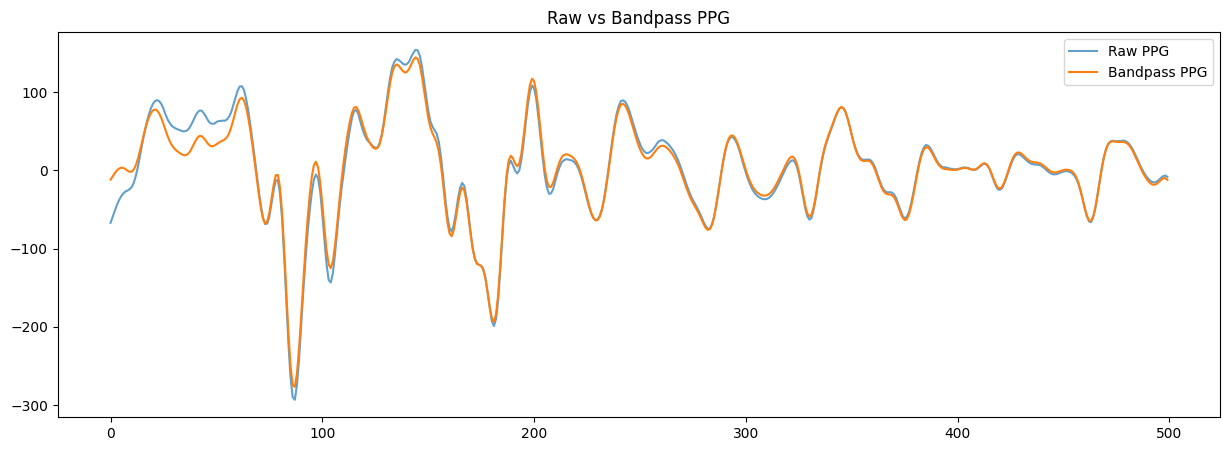

In [78]:
plt.figure(figsize=(15,5))

plt.plot(
    ppg_window[:500],
    label="Raw PPG",
    alpha=0.7
)

plt.plot(
    ppg_filtered[:500],
    label="Bandpass PPG"
)

plt.legend()

plt.title(
    "Raw vs Bandpass PPG"
)

plt.show()

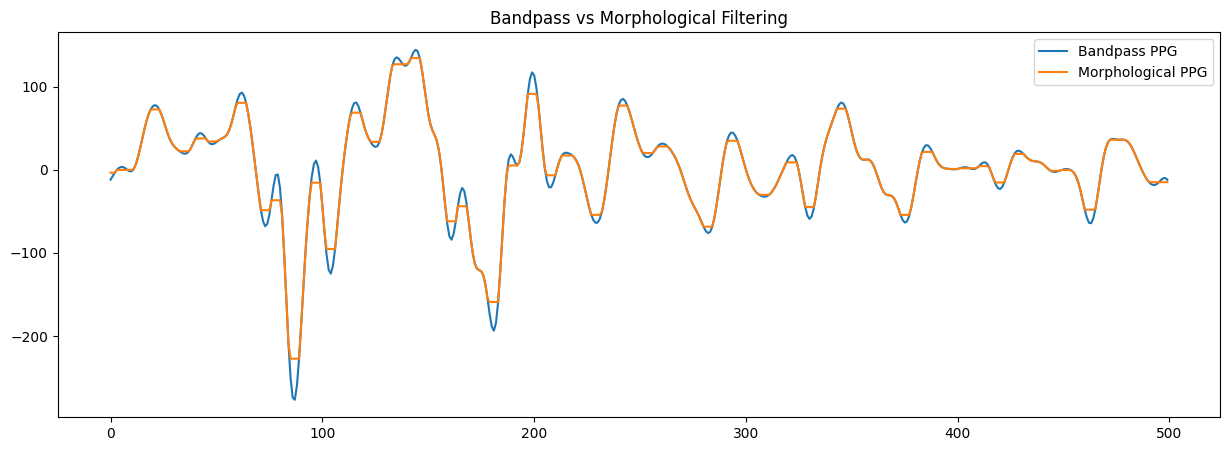

In [79]:
plt.figure(figsize=(15,5))

plt.plot(
    ppg_filtered[:500],
    label="Bandpass PPG"
)

plt.plot(
    ppg_morph[:500],
    label="Morphological PPG"
)

plt.legend()

plt.title(
    "Bandpass vs Morphological Filtering"
)

plt.show()

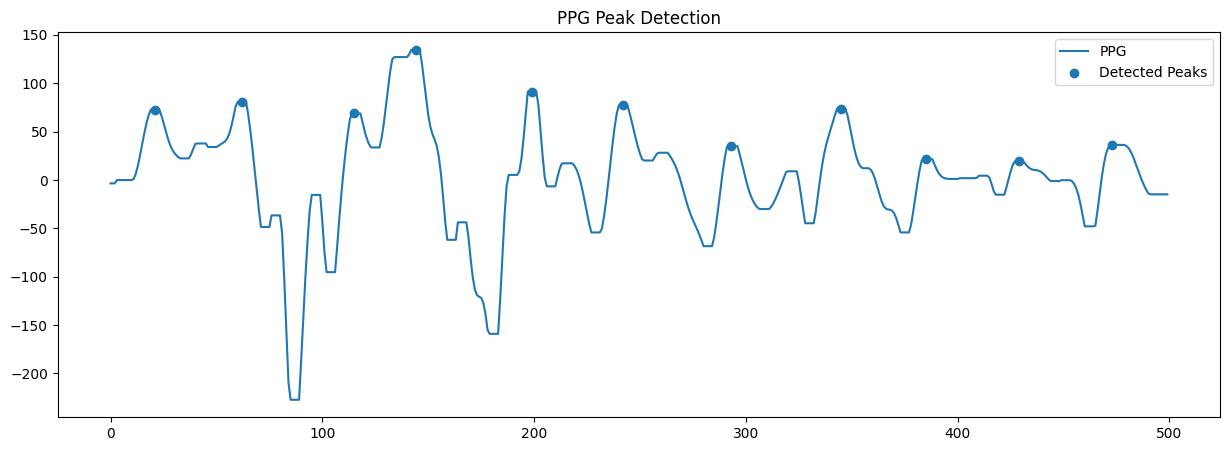

In [80]:
plt.figure(figsize=(15,5))

plt.plot(
    ppg_morph[:500],
    label="PPG"
)

valid_peaks = peaks[peaks < 500]

plt.scatter(
    valid_peaks,
    ppg_morph[valid_peaks],
    marker="o",
    label="Detected Peaks"
)

plt.legend()

plt.title(
    "PPG Peak Detection"
)

plt.show()

In [81]:
eda_window = eda_windows[0]

print(type(eda_window))
print(len(eda_window))

<class 'numpy.ndarray'>
240


LOW_PASS FILTER

In [82]:
from scipy.signal import butter
from scipy.signal import filtfilt

In [83]:
def lowpass_filter(signal,
                   cutoff=1,
                   fs=4,
                   order=4):

    nyquist = 0.5 * fs

    cutoff = cutoff / nyquist

    b, a = butter(
        order,
        cutoff,
        btype='low'
    )

    filtered = filtfilt(
        b,
        a,
        signal
    )

    return filtered

In [84]:
eda_filtered = lowpass_filter(
    eda_window
)

print(
    eda_filtered.shape
)

(240,)


TONIC -PHASIC DECOMPOSITION

In [85]:
eda_signals, eda_info = nk.eda_process(
    eda_filtered,
    sampling_rate=4
)

c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(


In [86]:
tonic = eda_signals[
    "EDA_Tonic"
]

phasic = eda_signals[
    "EDA_Phasic"
]

In [87]:
print(eda_signals.columns)

Index(['EDA_Raw', 'EDA_Clean', 'EDA_Tonic', 'EDA_Phasic', 'SCR_Onsets',
       'SCR_Peaks', 'SCR_Height', 'SCR_Amplitude', 'SCR_RiseTime',
       'SCR_Recovery', 'SCR_RecoveryTime'],
      dtype='object')


In [88]:
print(
    tonic.shape
)

print(
    phasic.shape
)

(240,)
(240,)


In [89]:
scr_threshold = (

    np.std(phasic)

    * 0.5

)

In [90]:
valid_scr = phasic[
    phasic > scr_threshold
]

In [91]:
if len(valid_scr) == 0:

    valid_scr = np.array(
        [0]
    )

In [92]:
scr_count = len(
    valid_scr
)

scr_mean_amp = np.mean(
    valid_scr
)

print(scr_count)
print(scr_mean_amp)

59
0.07741126681785958


In [93]:
scr_energy = np.sum(
    phasic**2
)

print(
    scr_energy
)

1.1009660538602404


In [94]:
hist, _ = np.histogram(
    phasic,
    bins=50,
    density=True
)

hist = hist + 1e-12

phasic_entropy = entropy(
    hist
)

print(
    phasic_entropy
)

3.297120676733572


In [95]:
activity,\
mobility,\
complexity = hjorth_parameters(
    phasic
)

print(activity)
print(mobility)
print(complexity)

0.004585353580518138
0.44020397700203345
1.9682072333890264


In [96]:
freqs, psd = welch(
    np.array(phasic),
    fs=4,
    nperseg=len(phasic)
)

In [97]:
psd_norm = psd / np.sum(psd)

spectral_entropy = entropy(
    psd_norm
)

print(
    spectral_entropy
)

3.170890872073436


In [98]:
print(scr_count)
print(scr_mean_amp)

print(scr_energy)

print(phasic_entropy)

print(activity)
print(mobility)
print(complexity)

print(spectral_entropy)

59
0.07741126681785958
1.1009660538602404
3.297120676733572
0.004585353580518138
0.44020397700203345
1.9682072333890264
3.170890872073436


In [99]:
print(ecg_windows.shape)
print(ppg_windows.shape)
print(eda_windows.shape)

print(type(ecg_windows))

(35, 42000)
(35, 3840)
(35, 240)
<class 'numpy.ndarray'>


In [100]:
for i in range(len(ecg_windows)):

    ecg_window = ecg_windows[i]
    ppg_window = ppg_windows[i]
    eda_window = eda_windows[i]

    print(
        f"Window {i+1}/{len(ecg_windows)}"
    )

Window 1/35
Window 2/35
Window 3/35
Window 4/35
Window 5/35
Window 6/35
Window 7/35
Window 8/35
Window 9/35
Window 10/35
Window 11/35
Window 12/35
Window 13/35
Window 14/35
Window 15/35
Window 16/35
Window 17/35
Window 18/35
Window 19/35
Window 20/35
Window 21/35
Window 22/35
Window 23/35
Window 24/35
Window 25/35
Window 26/35
Window 27/35
Window 28/35
Window 29/35
Window 30/35
Window 31/35
Window 32/35
Window 33/35
Window 34/35
Window 35/35


In [101]:
print(bandpass_filter)
print(swt_denoise)
print(morphology_filter)
print(lowpass_filter)
print(hjorth_parameters)

<function bandpass_filter at 0x000002098EB20180>
<function swt_denoise at 0x000002098EB20F40>
<function morphology_filter at 0x00000209AC77C7C0>
<function lowpass_filter at 0x00000209AC740FE0>
<function hjorth_parameters at 0x00000209ACCE4CC0>


In [102]:
def extract_ecg_features(ecg_window):

    try:

        ecg_filtered = bandpass_filter(
            ecg_window,
            lowcut=0.5,
            highcut=40,
            fs=700
        )

        ecg_swt = swt_denoise(
            ecg_filtered
        )

        signals, info = nk.ecg_process(
            ecg_swt,
            sampling_rate=700
        )

        r_peaks = info["ECG_R_Peaks"]

        if len(r_peaks) < 3:
            return None

        rr = np.diff(r_peaks) / 700

        ecg_mean_rr = np.mean(rr)

        std_rr = np.std(rr)

        rmssd = np.sqrt(
            np.mean(
                np.diff(rr)**2
            )
        )

        heart_rate = (
            60 / mean_rr
        )

        ecg_sample_entropy = ant.sample_entropy(rr)

        if not np.isfinite(sample_entropy):
            ecg_sample_entropy = 0

        rr1 = rr[:-1]
        rr2 = rr[1:]

        sd1 = np.sqrt(
            np.var(
                rr2 - rr1
            ) / 2
        )

        sd2 = np.sqrt(
            2*np.var(rr)
            -
            sd1**2
        )

        sd1_sd2 = (
            sd1
            /
            (sd2 + 1e-8)
        )

        freqs, psd = welch(
            rr,
            fs=4
        )

        lf_band = (
            (freqs >= 0.04)
            &
            (freqs < 0.15)
        )

        hf_band = (
            (freqs >= 0.15)
            &
            (freqs < 0.40)
        )

        lf_power = np.trapezoid(
            psd[lf_band]
        )

        hf_power = np.trapezoid(
            psd[hf_band]
        )

        lf_hf_ratio = (
            lf_power
            /
            (hf_power + 1e-8)
        )

        return {

            "ecg_mean_rr": ecg_mean_rr,
            "std_rr": std_rr,
            "rmssd": rmssd,
            "heart_rate": heart_rate,

            "ecg_sample_entropy":
            ecg_sample_entropy,

            "sd1": sd1,
            "sd2": sd2,

            "sd1_sd2":
            sd1_sd2,

            "lf_power":
            lf_power,

            "hf_power":
            hf_power,

            "lf_hf_ratio":
            lf_hf_ratio
        }

    except Exception as e:

        print(
            "ECG ERROR:",
            e
        )

        return None

In [103]:
ecg_test = extract_ecg_features(
    ecg_windows[0]
)

print(ecg_test)

{'ecg_mean_rr': np.float64(0.7428035714285715), 'std_rr': np.float64(0.09570880681280387), 'rmssd': np.float64(0.06542036636092166), 'heart_rate': np.float64(80.77505589345385), 'ecg_sample_entropy': 1.0655514264072217, 'sd1': np.float64(0.04624006642855206), 'sd2': np.float64(0.12720930649816592), 'sd1_sd2': np.float64(0.3634959113173031), 'lf_power': np.float64(0.004344037925740966), 'hf_power': np.float64(0.11786727651883801), 'lf_hf_ratio': np.float64(0.03685533156858316)}


C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 80, using nperseg = 80
  freqs, psd = welch(


In [104]:
def extract_ppg_features(ppg_window):

    try:

        # --------------------------------
        # Bandpass Filtering
        # --------------------------------

        ppg_filtered = bandpass_filter(
            ppg_window,
            lowcut=0.5,
            highcut=8,
            fs=64
        )

        # --------------------------------
        # Morphological Filtering
        # --------------------------------

        ppg_morph = morphology_filter(
            ppg_filtered
        )

        # --------------------------------
        # Peak Detection
        # --------------------------------

        signals, info = nk.ppg_process(
            ppg_morph,
            sampling_rate=64
        )

        peaks = info["PPG_Peaks"]

        if len(peaks) < 3:
            return None

        # --------------------------------
        # IBI Extraction
        # --------------------------------

        ibi = np.diff(peaks) / 64

        median_ibi = np.median(
            ibi
        )

        valid_mask = (

            (ibi > 0.5 * median_ibi)

            &

            (ibi < 1.5 * median_ibi)

        )

        ibi_refined = ibi[
            valid_mask
        ]

        if len(ibi_refined) < 3:
            return None

        # --------------------------------
        # Basic Features
        # --------------------------------

        mean_ibi = np.mean(
            ibi_refined
        )

        std_ibi = np.std(
            ibi_refined
        )

        pulse_rate = (
            60 /
            mean_ibi
        )

        pulse_var = np.var(
            ibi_refined
        )

        # --------------------------------
        # Sample Entropy
        # --------------------------------

        sample_entropy = ant.sample_entropy(
            ibi_refined
        )

        if not np.isfinite(sample_entropy):
            sample_entropy = 0

        # --------------------------------
        # Spectral Entropy
        # --------------------------------

        freqs, psd = welch(
            ppg_morph,
            fs=64,
            nperseg=len(
                ppg_morph
            )
        )

        psd_norm = (
            psd /
            np.sum(psd)
        )

        spectral_entropy = entropy(
            psd_norm
        )

        # --------------------------------
        # Pulse Width
        # --------------------------------

        pulse_widths = []

        for i in range(
            len(peaks)-1
        ):

            width = (

                peaks[i+1]

                -

                peaks[i]

            ) / 64

            pulse_widths.append(
                width
            )

        pulse_width_mean = np.mean(
            pulse_widths
        )

        pulse_width_std = np.std(
            pulse_widths
        )

        # --------------------------------
        # Fractal Features
        # --------------------------------

        hfd = ant.higuchi_fd(
            ppg_morph
        )

        dfa = ant.detrended_fluctuation(
            ppg_morph
        )

        # --------------------------------
        # Hjorth Parameters
        # --------------------------------

        activity,\
        mobility,\
        complexity = hjorth_parameters(
            ppg_morph
        )

        # --------------------------------
        # Return
        # --------------------------------

        return {

            "mean_ibi":
            mean_ibi,

            "std_ibi":
            std_ibi,

            "pulse_rate":
            pulse_rate,

            "pulse_var":
            pulse_var,

            "ppg_sample_entropy":
            ppg_sample_entropy,

            "spectral_entropy":
            spectral_entropy,

            "pulse_width_mean":
            pulse_width_mean,

            "pulse_width_std":
            pulse_width_std,

            "higuchi_fd":
            hfd,

            "dfa":
            dfa,

            "ppg_hjorth_activity":
            activity,

            "ppg_hjorth_mobility":
            mobility,

            "ppg_hjorth_complexity":
            complexity
        }

    except Exception as e:

        print(
            "PPG ERROR:",
            e
        )

        return None

In [105]:
ppg_test = extract_ppg_features(
    ppg_windows[0]
)

print(ppg_test)

{'mean_ibi': np.float64(0.7309283088235294), 'std_ibi': np.float64(0.18311833369237576), 'pulse_rate': np.float64(82.0873939012889), 'pulse_var': np.float64(0.033532324134272276), 'ppg_sample_entropy': 2.1102132003465894, 'spectral_entropy': np.float64(4.553632142489044), 'pulse_width_mean': np.float64(0.7444620253164557), 'pulse_width_std': np.float64(0.24079470084837332), 'higuchi_fd': 1.0482939177451611, 'dfa': 1.0300081785970494, 'ppg_hjorth_activity': np.float64(9952.475316833361), 'ppg_hjorth_mobility': np.float64(0.1698387040311078), 'ppg_hjorth_complexity': np.float64(2.6355769201493615)}


In [106]:
def extract_eda_features(eda_window):

    try:

        # --------------------------
        # Lowpass Filtering
        # --------------------------

        eda_filtered = lowpass_filter(
            eda_window
        )

        # --------------------------
        # Tonic / Phasic
        # --------------------------

        eda_signals, eda_info = nk.eda_process(
            eda_filtered,
            sampling_rate=4
        )

        tonic = eda_signals[
            "EDA_Tonic"
        ]

        phasic = eda_signals[
            "EDA_Phasic"
        ]

        phasic_np = (
            phasic.to_numpy()
        )

        # --------------------------
        # Adaptive SCR
        # --------------------------

        scr_threshold = (

            np.std(phasic_np)

            * 0.5

        )

        valid_scr = phasic_np[
            phasic_np > scr_threshold
        ]

        if len(valid_scr) == 0:

            valid_scr = np.array(
                [0]
            )

        scr_count = len(
            valid_scr
        )

        scr_mean_amp = np.mean(
            valid_scr
        )

        # --------------------------
        # SCR Energy
        # --------------------------

        scr_energy = np.sum(
            phasic_np**2
        )

        # --------------------------
        # Phasic Entropy
        # --------------------------

        hist, _ = np.histogram(
            phasic_np,
            bins=50,
            density=True
        )

        hist = hist + 1e-12

        phasic_entropy = entropy(
            hist
        )

        # --------------------------
        # Hjorth
        # --------------------------

        activity,\
        mobility,\
        complexity = hjorth_parameters(
            phasic_np
        )

        # --------------------------
        # Spectral Entropy
        # --------------------------

        freqs, psd = welch(
            phasic_np,
            fs=4,
            nperseg=len(
                phasic_np
            )
        )

        psd_norm = (
            psd /
            np.sum(psd)
        )

        eda_spectral_entropy = entropy(
            psd_norm
        )

        return {

            "scr_count":
            scr_count,

            "scr_mean_amp":
            scr_mean_amp,

            "scr_energy":
            scr_energy,

            "phasic_entropy":
            phasic_entropy,

            "hjorth_activity":
            activity,

            "hjorth_mobility":
            mobility,

            "hjorth_complexity":
            complexity,

            "eda_spectral_entropy":
            eda_spectral_entropy
        }

    except Exception as e:

        print(
            "EDA ERROR:",
            e
        )

        return None

In [107]:
eda_test = extract_eda_features(
    eda_windows[0]
)

print(eda_test)

{'scr_count': 59, 'scr_mean_amp': np.float64(0.07741126681785958), 'scr_energy': np.float64(1.1009660538602404), 'phasic_entropy': np.float64(3.297120676733572), 'hjorth_activity': np.float64(0.004585353580518138), 'hjorth_mobility': np.float64(0.44020397700203345), 'hjorth_complexity': np.float64(1.9682072333890264), 'eda_spectral_entropy': np.float64(3.170890872073436)}


c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(


In [108]:
X_handcrafted = []

for i in range(len(ecg_windows)):

    ecg_feat = extract_ecg_features(
        ecg_windows[i]
    )

    ppg_feat = extract_ppg_features(
        ppg_windows[i]
    )

    eda_feat = extract_eda_features(
        eda_windows[i]
    )

    if (

        ecg_feat is None

        or

        ppg_feat is None

        or

        eda_feat is None

    ):

        continue

    combined = {

        **ecg_feat,

        **ppg_feat,

        **eda_feat
    }

    X_handcrafted.append(
        combined
    )

C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 80, using nperseg = 80
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 69, using nperseg = 69
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 73, using nperseg = 73
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Deskt

In [109]:
print(
    len(X_handcrafted)
)

35


In [110]:
df_features = pd.DataFrame(
    X_handcrafted
)

print(
    df_features.shape
)

(35, 32)


In [111]:
print(df_features.columns.tolist())

['ecg_mean_rr', 'std_rr', 'rmssd', 'heart_rate', 'ecg_sample_entropy', 'sd1', 'sd2', 'sd1_sd2', 'lf_power', 'hf_power', 'lf_hf_ratio', 'mean_ibi', 'std_ibi', 'pulse_rate', 'pulse_var', 'ppg_sample_entropy', 'spectral_entropy', 'pulse_width_mean', 'pulse_width_std', 'higuchi_fd', 'dfa', 'ppg_hjorth_activity', 'ppg_hjorth_mobility', 'ppg_hjorth_complexity', 'scr_count', 'scr_mean_amp', 'scr_energy', 'phasic_entropy', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'eda_spectral_entropy']


In [112]:
print(len(df_features.columns))

32


In [113]:
print(df_features.shape)
print(df_features.isnull().sum().sum())

(35, 32)
0


In [114]:
print(df_features.isnull().sum())

ecg_mean_rr              0
std_rr                   0
rmssd                    0
heart_rate               0
ecg_sample_entropy       0
sd1                      0
sd2                      0
sd1_sd2                  0
lf_power                 0
hf_power                 0
lf_hf_ratio              0
mean_ibi                 0
std_ibi                  0
pulse_rate               0
pulse_var                0
ppg_sample_entropy       0
spectral_entropy         0
pulse_width_mean         0
pulse_width_std          0
higuchi_fd               0
dfa                      0
ppg_hjorth_activity      0
ppg_hjorth_mobility      0
ppg_hjorth_complexity    0
scr_count                0
scr_mean_amp             0
scr_energy               0
phasic_entropy           0
hjorth_activity          0
hjorth_mobility          0
hjorth_complexity        0
eda_spectral_entropy     0
dtype: int64


In [115]:
import numpy as np

print(np.isinf(df_features).sum())

ecg_mean_rr              0
std_rr                   0
rmssd                    0
heart_rate               0
ecg_sample_entropy       0
sd1                      0
sd2                      0
sd1_sd2                  0
lf_power                 0
hf_power                 0
lf_hf_ratio              0
mean_ibi                 0
std_ibi                  0
pulse_rate               0
pulse_var                0
ppg_sample_entropy       0
spectral_entropy         0
pulse_width_mean         0
pulse_width_std          0
higuchi_fd               0
dfa                      0
ppg_hjorth_activity      0
ppg_hjorth_mobility      0
ppg_hjorth_complexity    0
scr_count                0
scr_mean_amp             0
scr_energy               0
phasic_entropy           0
hjorth_activity          0
hjorth_mobility          0
hjorth_complexity        0
eda_spectral_entropy     0
dtype: int64


In [116]:
for col in df_features.columns:

    if df_features[col].isnull().any():

        print("NaN found in:", col)

In [117]:
for col in df_features.columns:

    if np.isinf(df_features[col]).any():

        print("Inf found in:", col)

In [118]:
import numpy as np

df_features = df_features.replace(
    [np.inf, -np.inf],
    np.nan
)

df_features = df_features.fillna(
    df_features.median()
)

In [119]:
print(df_features.isnull().sum().sum())

print(
    np.isinf(
        df_features
    ).sum().sum()
)

0
0


In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df_features
)

print(X_scaled.shape)

(35, 32)


In [121]:
df_features = df_features.replace(
    [np.inf, -np.inf],
    np.nan
)

df_features = df_features.fillna(
    df_features.median()
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df_features
)

print(X_scaled.shape)

(35, 32)


In [122]:
print(df_features.shape)

print(X_scaled.shape)

print(np.isnan(X_scaled).sum())

print(np.isinf(X_scaled).sum())

(35, 32)
(35, 32)
0
0


In [123]:
subjects = [

    "S2","S3","S4","S5",
    "S6","S7","S8","S9",
    "S10","S11","S13","S14",
    "S15","S16","S17"

]

In [124]:
all_features = []

all_labels = []

subject_ids = []

for subject in subjects:

    print(
        f"\nProcessing {subject}"
    )

    ecg, ppg, eda, labels = (
        load_subject(subject)
    )

    valid_segments = (
        get_valid_segments(labels)
    )

    (
        ecg_windows,
        ppg_windows,
        eda_windows,
        window_labels
    ) = create_windows(

        ecg,
        ppg,
        eda,
        valid_segments
    )

    print(
        "Windows:",
        len(ecg_windows)
    )

    for i in range(
        len(ecg_windows)
    ):

        ecg_feat = (
            extract_ecg_features(
                ecg_windows[i]
            )
        )

        ppg_feat = (
            extract_ppg_features(
                ppg_windows[i]
            )
        )

        eda_feat = (
            extract_eda_features(
                eda_windows[i]
            )
        )

        if (

            ecg_feat is None

            or

            ppg_feat is None

            or

            eda_feat is None

        ):

            continue

        combined = {

            **ecg_feat,

            **ppg_feat,

            **eda_feat
        }

        all_features.append(
            combined
        )

        all_labels.append(
            window_labels[i]
        )

        subject_ids.append(
            subject
        )


Processing S2
Windows: 35


C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 80, using nperseg = 80
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 69, using nperseg = 69
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 73, using nperseg = 73
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Deskt


Processing S3
Windows: 35


C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 56, using nperseg = 56
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 55, using nperseg = 55
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 52, using nperseg = 52
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Deskt


Processing S4
Windows: 35


...

C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 80, using nperseg = 80
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 79, using nperseg = 79
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 81, using nperseg = 81
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Deskt


Processing S16
Windows: 36


C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 65, using nperseg = 65
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 60, using nperseg = 60
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 64, using nperseg = 64
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Deskt


Processing S17
Windows: 37


C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 73, using nperseg = 73
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 66, using nperseg = 66
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
C:\Users\AMRITHA\AppData\Local\Temp\ipykernel_972\772060380.py:68: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 62, using nperseg = 62
  freqs, psd = welch(
c:\Users\AMRITHA\OneDrive\Deskt

In [125]:
print(
    len(all_features)
)

print(
    len(all_labels)
)

print(
    len(subject_ids)
)

535
535
535


In [126]:
df_all = pd.DataFrame(
    all_features
)

In [127]:
print(df_all.shape)

(535, 32)


In [128]:
df_all = df_all.replace(
    [np.inf, -np.inf],
    np.nan
)

df_all = df_all.fillna(
    df_all.median()
)

In [129]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_handcrafted = scaler.fit_transform(
    df_all
)

In [130]:
y = np.array(
    all_labels
)

subjects_array = np.array(
    subject_ids
)

In [131]:
print(df_all.shape)

print(y.shape)

print(subjects_array.shape)

print(np.unique(y))

(535, 32)
(535,)
(535,)
[1 2 3]


In [132]:
print(df_all.isnull().sum().sum())

print(np.isinf(df_all).sum().sum())

0
0


In [133]:
print(np.unique(y))

[1 2 3]


In [134]:
X = df_all.copy()

y = np.array(all_labels)

print(X.shape)
print(y.shape)

(535, 32)
(535,)


In [135]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median()
)

In [136]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(535, 32)


In [137]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_handcrafted = scaler.fit_transform(
    df_all
)

In [138]:
print(type(ecg_windows))
print(len(ecg_windows))

print(type(ppg_windows))
print(len(ppg_windows))

print(type(eda_windows))
print(len(eda_windows))

<class 'list'>
37
<class 'list'>
37
<class 'list'>
37


In [139]:
print(type(all_features))
print(len(all_features))

print(type(all_labels))
print(len(all_labels))

print(type(subject_ids))
print(len(subject_ids))

<class 'list'>
535
<class 'list'>
535
<class 'list'>
535


In [140]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'np', 'pd', 'nk', 'pywt', 'pickle', 'butter', 'filtfilt', 'welch', 'entropy', '_i2', 'bandpass_filter', '_i3', 'wavelet_denoise', '_i4', 'subjects', '_i5', 'load_subject', '_i6', 'ecg', 'ppg', 'eda', 'labels', '_i7', 'preprocess_subject', '_i8', 'ecg_p', 'ppg_p', 'eda_p', 'tonic', 'phasic', '_i9', 'get_valid_segments', '_i10', 'segments', 'seg', '_i11', 'label', 'start', 'end', 'duration_sec', '_i12', 'create_windows', '_i13', 'ecg_windows', 'ppg_windows', 'eda_windows', 'window_labels', '_i14', '_i15', '_i16', 'ecg_window', '_i17', '_i18', 'max_level', '_i19', '_i20', '_i21', 'ecg_filtered', '_i22', 'shannon_entropy', '_i23', '_i24', 'swt_denoise', '_i25', 'ecg_swt', '_i26', 'plt', '_i27', 'signals', 'info', 'r_peaks', '_i28', 'rr', '_i29', '

In [141]:
[var for var in globals() if "ecg" in var.lower()]

['ecg',
 'ecg_p',
 'ecg_windows',
 'ecg_window',
 'ecg_filtered',
 'ecg_swt',
 'ecg_features',
 'extract_ecg_features',
 'ecg_test',
 'ecg_feat']

In [142]:
print(type(all_features))
print(len(all_features))

print(type(all_labels))
print(len(all_labels))

print(type(subject_ids))
print(len(subject_ids))

<class 'list'>
535
<class 'list'>
535
<class 'list'>
535


In [143]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(np.unique(y_encoded))
print(np.bincount(y_encoded))

[0 1 2]
[285 160  90]


In [144]:
print("X_ecg_s1" in globals())
print("X_ppg_s1" in globals())
print("X_eda_s1" in globals())
print("X_scaled" in globals())
print("y_encoded" in globals())

False
False
False
True
True


In [145]:
for var in [
    "X_ecg_s1","X_ecg_s2","X_ecg_s3",
    "X_ppg_s1","X_ppg_s2","X_ppg_s3",
    "X_eda_s1","X_eda_s2","X_eda_s3",
    "X_scaled","y_encoded"
]:
    print(var, var in globals())

X_ecg_s1 False
X_ecg_s2 False
X_ecg_s3 False
X_ppg_s1 False
X_ppg_s2 False
X_ppg_s3 False
X_eda_s1 False
X_eda_s2 False
X_eda_s3 False
X_scaled True
y_encoded True


In [146]:
print(type(ecg_windows))
print(len(ecg_windows))

print(type(ppg_windows))
print(len(ppg_windows))

print(type(eda_windows))
print(len(eda_windows))

<class 'list'>
37
<class 'list'>
37
<class 'list'>
37


In [147]:
print(np.array(ecg_windows).shape)
print(np.array(ppg_windows).shape)
print(np.array(eda_windows).shape)

(37, 42000)
(37, 3840)
(37, 240)


In [148]:
print(len(all_features))
print(len(all_labels))

535
535


In [149]:
print(len(subject_ids))

535


In [150]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [151]:
def cnn_branch(inp, filters):

    x = Conv1D(
        filters,
        kernel_size=5,
        padding='same',
        activation='relu'
    )(inp)

    x = BatchNormalization()(x)

    x = MaxPooling1D(2)(x)

    x = Conv1D(
        filters,
        kernel_size=3,
        padding='same',
        activation='relu'
    )(x)

    x = GlobalAveragePooling1D()(x)

    return x

In [152]:
ecg_input_1 = Input((1000,1))
ppg_input_1 = Input((1000,1))
eda_input_1 = Input((240,1))

ecg_input_2 = Input((500,1))
ppg_input_2 = Input((500,1))
eda_input_2 = Input((120,1))

ecg_input_3 = Input((250,1))
ppg_input_3 = Input((250,1))
eda_input_3 = Input((60,1))

handcrafted_input = Input((32,))

In [153]:
ecg_s1 = cnn_branch(ecg_input_1,32)
ppg_s1 = cnn_branch(ppg_input_1,32)
eda_s1 = cnn_branch(eda_input_1,16)

ecg_s2 = cnn_branch(ecg_input_2,32)
ppg_s2 = cnn_branch(ppg_input_2,32)
eda_s2 = cnn_branch(eda_input_2,16)

ecg_s3 = cnn_branch(ecg_input_3,32)
ppg_s3 = cnn_branch(ppg_input_3,32)
eda_s3 = cnn_branch(eda_input_3,16)

In [154]:
scale1 = Concatenate()(
    [ecg_s1, ppg_s1, eda_s1]
)

scale2 = Concatenate()(
    [ecg_s2, ppg_s2, eda_s2]
)

scale3 = Concatenate()(
    [ecg_s3, ppg_s3, eda_s3]
)

In [155]:
scale1 = Dense(64,activation='relu')(scale1)
scale2 = Dense(64,activation='relu')(scale2)
scale3 = Dense(64,activation='relu')(scale3)

In [156]:
scale1 = Reshape((1,64))(scale1)
scale2 = Reshape((1,64))(scale2)
scale3 = Reshape((1,64))(scale3)

In [157]:
msc_mat = Concatenate(axis=1)(
    [
        scale1,
        scale2,
        scale3
    ]
)

In [158]:
attn = MultiHeadAttention(
    num_heads=4,
    key_dim=16
)(
    msc_mat,
    msc_mat
)

x = Add()(
    [
        msc_mat,
        attn
    ]
)

x = LayerNormalization()(x)

In [159]:
x = Bidirectional(
    GRU(
        64,
        return_sequences=True
    )
)(x)

In [160]:
attn2 = MultiHeadAttention(
    num_heads=4,
    key_dim=16
)(
    x,
    x
)

x = Add()(
    [
        x,
        attn2
    ]
)

x = LayerNormalization()(x)

In [161]:
ff = Dense(
    128,
    activation='relu'
)(x)

ff = Dense(
    128
)(ff)

x = Add()(
    [
        x,
        ff
    ]
)

x = LayerNormalization()(x)

In [162]:
x = GlobalAveragePooling1D()(x)

In [163]:
fusion = Concatenate()(
    [
        x,
        handcrafted_input
    ]
)

In [164]:
fusion = Dense(
    128,
    activation='relu'
)(fusion)

fusion = Dropout(
    0.4
)(fusion)

fusion = Dense(
    64,
    activation='relu'
)(fusion)

fusion = Dropout(
    0.3
)(fusion)

output = Dense(
    3,
    activation='softmax'
)(fusion)

In [165]:
model = Model(

    inputs=[

        ecg_input_1,
        ppg_input_1,
        eda_input_1,

        ecg_input_2,
        ppg_input_2,
        eda_input_2,

        ecg_input_3,
        ppg_input_3,
        eda_input_3,

        handcrafted_input

    ],

    outputs=output
)

In [166]:
model.compile(

    optimizer=Adam(
        learning_rate=1e-4
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [167]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 240, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 500, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 500, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 120, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 250, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 250, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1000, 32)  │        192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1000, 32)  │        192 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 240, 16)   │         96 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 500, 32)   │        192 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 500, 32)   │        192 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 120, 16)   │         96 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 250, 32)   │        192 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 250, 32)   │        192 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 60, 16)    │         96 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1000, 32)  │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 32)  │        128 │ conv1d_2[0][0]  

 Total params: 201,299 (786.32 KB)

 Trainable params: 200,819 (784.45 KB)

 Non-trainable params: 480 (1.88 KB)

In [197]:
X_ecg_s1 = []
X_ppg_s1 = []
X_eda_s1 = []

X_ecg_s2 = []
X_ppg_s2 = []
X_eda_s2 = []

X_ecg_s3 = []
X_ppg_s3 = []
X_eda_s3 = []

y_all = []

print(type(X_ecg_s1))
print(type(X_ppg_s1))
print(type(X_eda_s1))

<class 'list'>
<class 'list'>
<class 'list'>


In [198]:
X_ecg_s1 = []
X_ecg_s2 = []
X_ecg_s3 = []

X_ppg_s1 = []
X_ppg_s2 = []
X_ppg_s3 = []

X_eda_s1 = []
X_eda_s2 = []
X_eda_s3 = []

y_all = []

In [199]:

def create_multiscale_signals(
    ecg,
    ppg,
    eda
):

    scale1 = {

        "ecg": ecg,

        "ppg": ppg,

        "eda": eda

    }

    scale2 = {

        "ecg": resample(
            ecg,
            500
        ),

        "ppg": resample(
            ppg,
            500
        ),

        "eda": resample(
            eda,
            120
        )

    }

    scale3 = {

        "ecg": resample(
            ecg,
            250
        ),

        "ppg": resample(
            ppg,
            250
        ),

        "eda": resample(
            eda,
            60
        )

    }

    return (
        scale1,
        scale2,
        scale3
    ) 

In [200]:
print(type(X_ecg_s1))
print(X_ecg_s1.shape if hasattr(X_ecg_s1, "shape") else "No shape")

<class 'list'>
No shape


In [201]:
for subject in subjects:

    print("Processing", subject)

    ecg, ppg, eda, labels = load_subject(subject)

    valid_segments = get_valid_segments(labels)

    valid_segments = [
        seg for seg in valid_segments
        if seg[0] in [1,2,3]
    ]

    (
        ecg_windows,
        ppg_windows,
        eda_windows,
        window_labels
    ) = create_windows(
        ecg,
        ppg,
        eda,
        valid_segments
    )

    for ecg_w, ppg_w, eda_w, lbl in zip(
        ecg_windows,
        ppg_windows,
        eda_windows,
        window_labels
    ):

        scale1, scale2, scale3 = create_multiscale_signals(
            ecg_w,
            ppg_w,
            eda_w
        )

        X_ecg_s1.append(
            scale1["ecg"].reshape(-1,1)
        )

        X_ppg_s1.append(
            scale1["ppg"].reshape(-1,1)
        )

        X_eda_s1.append(
            scale1["eda"].reshape(-1,1)
        )

        X_ecg_s2.append(
            scale2["ecg"].reshape(-1,1)
        )

        X_ppg_s2.append(
            scale2["ppg"].reshape(-1,1)
        )

        X_eda_s2.append(
            scale2["eda"].reshape(-1,1)
        )

        X_ecg_s3.append(
            scale3["ecg"].reshape(-1,1)
        )

        X_ppg_s3.append(
            scale3["ppg"].reshape(-1,1)
        )

        X_eda_s3.append(
            scale3["eda"].reshape(-1,1)
        )

        y_all.append(lbl)

Processing S2
Processing S3
Processing S4
Processing S5
Processing S6
Processing S7
Processing S8
Processing S9
Processing S10
Processing S11
Processing S13
Processing S14
Processing S15
Processing S16
Processing S17


In [202]:
import numpy as np

X_ecg_s1 = np.array(X_ecg_s1)
X_ecg_s2 = np.array(X_ecg_s2)
X_ecg_s3 = np.array(X_ecg_s3)

X_ppg_s1 = np.array(X_ppg_s1)
X_ppg_s2 = np.array(X_ppg_s2)
X_ppg_s3 = np.array(X_ppg_s3)

X_eda_s1 = np.array(X_eda_s1)
X_eda_s2 = np.array(X_eda_s2)
X_eda_s3 = np.array(X_eda_s3)

y_all = np.array(y_all)

In [203]:
print(X_ecg_s1.shape)
print(X_ecg_s2.shape)
print(X_ecg_s3.shape)

print(X_ppg_s1.shape)
print(X_ppg_s2.shape)
print(X_ppg_s3.shape)

print(X_eda_s1.shape)
print(X_eda_s2.shape)
print(X_eda_s3.shape)

print(y_all.shape)
print(np.unique(y_all))

(535, 42000, 1)
(535, 500, 1)
(535, 250, 1)
(535, 3840, 1)
(535, 500, 1)
(535, 250, 1)
(535, 240, 1)
(535, 120, 1)
(535, 60, 1)
(535,)
[1 2 3]


In [204]:
from scipy.signal import resample

X_ecg_s1 = np.array([
    resample(x.squeeze(), 1000).reshape(1000,1)
    for x in X_ecg_s1
])

X_ppg_s1 = np.array([
    resample(x.squeeze(), 1000).reshape(1000,1)
    for x in X_ppg_s1
])

X_eda_s1 = np.array([
    x.reshape(240,1)
    for x in X_eda_s1
])

In [205]:
print(X_ecg_s1.shape)
print(X_ppg_s1.shape)
print(X_eda_s1.shape)

(535, 1000, 1)
(535, 1000, 1)
(535, 240, 1)


In [206]:
print(X_ecg_s1.shape)
print(X_ecg_s2.shape)
print(X_ecg_s3.shape)

print(X_ppg_s1.shape)
print(X_ppg_s2.shape)
print(X_ppg_s3.shape)

print(X_eda_s1.shape)
print(X_eda_s2.shape)
print(X_eda_s3.shape)

(535, 1000, 1)
(535, 500, 1)
(535, 250, 1)
(535, 1000, 1)
(535, 500, 1)
(535, 250, 1)
(535, 240, 1)
(535, 120, 1)
(535, 60, 1)


In [207]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y_all)

print(np.unique(y_encoded))
print(np.bincount(y_encoded))

[0 1 2]
[285 160  90]


In [208]:
from sklearn.model_selection import train_test_split

(
X_ecg_s1_train, X_ecg_s1_test,
X_ppg_s1_train, X_ppg_s1_test,
X_eda_s1_train, X_eda_s1_test,

X_ecg_s2_train, X_ecg_s2_test,
X_ppg_s2_train, X_ppg_s2_test,
X_eda_s2_train, X_eda_s2_test,

X_ecg_s3_train, X_ecg_s3_test,
X_ppg_s3_train, X_ppg_s3_test,
X_eda_s3_train, X_eda_s3_test,

X_hand_train, X_hand_test,

y_train, y_test

) = train_test_split(

    X_ecg_s1,
    X_ppg_s1,
    X_eda_s1,

    X_ecg_s2,
    X_ppg_s2,
    X_eda_s2,

    X_ecg_s3,
    X_ppg_s3,
    X_eda_s3,

    X_scaled,

    y_encoded,

    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [209]:
print(len(X_ecg_s1))
print(len(X_ppg_s1))
print(len(X_eda_s1))

print(len(X_ecg_s2))
print(len(X_ppg_s2))
print(len(X_eda_s2))

print(len(X_ecg_s3))
print(len(X_ppg_s3))
print(len(X_eda_s3))

print(len(X_scaled))
print(len(y_encoded))
print(len(X_ecg_s1))
print(len(X_ppg_s1))
print(len(X_eda_s1))

print(len(X_ecg_s2))
print(len(X_ppg_s2))
print(len(X_eda_s2))

print(len(X_ecg_s3))
print(len(X_ppg_s3))
print(len(X_eda_s3))

print(len(X_scaled))
print(len(y_encoded))

535
535
535
535
535
535
535
535
535
535
535
535
535
535
535
535
535
535
535
535
535
535


In [210]:
subject = subjects[0]

ecg, ppg, eda, labels = load_subject(subject)

print(ecg.shape)
print(ppg.shape)
print(eda.shape)
print(labels.shape)

(4255300,)
(389056,)
(24316,)
(4255300,)


In [211]:
valid_segments = get_valid_segments(labels)

print(len(valid_segments))

print(valid_segments[:5])

3
[(np.int32(1), 214583, 1015382), (np.int32(2), 1591482, 2021981), (np.int32(3), 3334483, 3587882)]


In [212]:
from tensorflow.keras.callbacks import *

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [213]:
history = model.fit(

    [

        X_ecg_s1_train,
        X_ppg_s1_train,
        X_eda_s1_train,

        X_ecg_s2_train,
        X_ppg_s2_train,
        X_eda_s2_train,

        X_ecg_s3_train,
        X_ppg_s3_train,
        X_eda_s3_train,

        X_hand_train

    ],

    y_train,

    validation_split=0.2,

    epochs=150,

    batch_size=16,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.4503 - loss: 1.1398 - val_accuracy: 0.6047 - val_loss: 1.0347 - learning_rate: 1.0000e-04
Epoch 2/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5994 - loss: 0.9635 - val_accuracy: 0.6047 - val_loss: 0.9590 - learning_rate: 1.0000e-04
Epoch 3/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6170 - loss: 0.8944 - val_accuracy: 0.6744 - val_loss: 0.8882 - learning_rate: 1.0000e-04
Epoch 4/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6199 - loss: 0.8565 - val_accuracy: 0.6628 - val_loss: 0.8748 - learning_rate: 1.0000e-04
Epoch 5/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6345 - loss: 0.8155 - val_accuracy: 0.6512 - val_loss: 0.8569 - learning_rate: 1.0000e-04
Epoch 6/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6988 - loss: 0.7527 - val_accuracy: 0.6860 - val_loss: 0.8253 - learning_rate: 1.0000e-04
Epoch 7/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy:

In [214]:
print(
    "Best Val Accuracy:",
    max(history.history['val_accuracy'])
)

Best Val Accuracy: 0.9418604373931885


In [215]:
print(max(history.history['accuracy']))
print(max(history.history['val_accuracy']))
print(len(history.history['accuracy']))

0.9678362607955933
0.9418604373931885
84


In [216]:
y_pred_prob = model.predict(

    [

        X_ecg_s1_test,
        X_ppg_s1_test,
        X_eda_s1_test,

        X_ecg_s2_test,
        X_ppg_s2_test,
        X_eda_s2_test,

        X_ecg_s3_test,
        X_ppg_s3_test,
        X_eda_s3_test,

        X_hand_test

    ]

)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 349ms/step


In [217]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", acc)

Accuracy: 0.9439252336448598


In [218]:
from sklearn.metrics import classification_report

print(

    classification_report(
        y_test,
        y_pred
    )

)

              precision    recall  f1-score   support

           0       0.95      0.96      0.96        57
           1       0.97      0.97      0.97        32
           2       0.88      0.83      0.86        18

    accuracy                           0.94       107
   macro avg       0.93      0.92      0.93       107
weighted avg       0.94      0.94      0.94       107



In [219]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[55  0  2]
 [ 1 31  0]
 [ 2  1 15]]


In [220]:
model.save(
    "MSC_MAT_CNN_BiGRU_Transformer.keras"
)

In [221]:
import os

for f in os.listdir():
    if f.endswith(".keras"):
        print(f)

MSC_MAT_CNN_BiGRU_Transformer.keras
MSC_MFF_Stress.keras
MSC_MFF_Transformer.keras
MSC_MFF_Transformer_Attention.keras
MSC_MFF_Transformer_Hybrid(final).keras
stress_cnn.keras
stress_cnn_bilstm.keras


In [222]:
import pickle

with open(
    "scaler.pkl",
    "wb"
) as f:
    pickle.dump(
        scaler,
        f
    )

In [223]:
with open(
    "label_encoder.pkl",
    "wb"
) as f:
    pickle.dump(
        label_encoder,
        f
    )

In [224]:
with open(
    "label_encoder.pkl",
    "wb"
) as f:
    pickle.dump(
        label_encoder,
        f
    )

In [225]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import tensorflow.keras.backend as K
import numpy as np

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_accuracies = []

for fold, (train_idx, test_idx) in enumerate(
    kfold.split(X_scaled, y_encoded),
    start=1
):

    print(f"\n========== FOLD {fold}/5 ==========")

    K.clear_session()

    model = build_model()

    # TRAIN DATA
    X_ecg_s1_train = X_ecg_s1[train_idx]
    X_ppg_s1_train = X_ppg_s1[train_idx]
    X_eda_s1_train = X_eda_s1[train_idx]

    X_ecg_s2_train = X_ecg_s2[train_idx]
    X_ppg_s2_train = X_ppg_s2[train_idx]
    X_eda_s2_train = X_eda_s2[train_idx]

    X_ecg_s3_train = X_ecg_s3[train_idx]
    X_ppg_s3_train = X_ppg_s3[train_idx]
    X_eda_s3_train = X_eda_s3[train_idx]

    X_hand_train = X_scaled[train_idx]

    y_train = y_encoded[train_idx]

    # TEST DATA
    X_ecg_s1_test = X_ecg_s1[test_idx]
    X_ppg_s1_test = X_ppg_s1[test_idx]
    X_eda_s1_test = X_eda_s1[test_idx]

    X_ecg_s2_test = X_ecg_s2[test_idx]
    X_ppg_s2_test = X_ppg_s2[test_idx]
    X_eda_s2_test = X_eda_s2[test_idx]

    X_ecg_s3_test = X_ecg_s3[test_idx]
    X_ppg_s3_test = X_ppg_s3[test_idx]
    X_eda_s3_test = X_eda_s3[test_idx]

    X_hand_test = X_scaled[test_idx]

    y_test = y_encoded[test_idx]

    history = model.fit(

        [

            X_ecg_s1_train,
            X_ppg_s1_train,
            X_eda_s1_train,

            X_ecg_s2_train,
            X_ppg_s2_train,
            X_eda_s2_train,

            X_ecg_s3_train,
            X_ppg_s3_train,
            X_eda_s3_train,

            X_hand_train

        ],

        y_train,

        validation_split=0.2,

        epochs=150,

        batch_size=16,

        callbacks=[
            early_stop,
            reduce_lr
        ],

        verbose=0
    )

    y_pred_prob = model.predict(

        [

            X_ecg_s1_test,
            X_ppg_s1_test,
            X_eda_s1_test,

            X_ecg_s2_test,
            X_ppg_s2_test,
            X_eda_s2_test,

            X_ecg_s3_test,
            X_ppg_s3_test,
            X_eda_s3_test,

            X_hand_test

        ],

        verbose=0
    )

    y_pred = np.argmax(
        y_pred_prob,
        axis=1
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    fold_accuracies.append(acc)

    print(
        f"Fold {fold} Accuracy = {acc*100:.2f}%"
    )

print("\n==============================")
print("5-FOLD CROSS VALIDATION")
print("==============================")

for i, acc in enumerate(
    fold_accuracies,
    start=1
):
    print(
        f"Fold {i}: {acc*100:.2f}%"
    )

print(
    "\nMean Accuracy:",
    np.mean(fold_accuracies)*100
)

print(
    "Std:",
    np.std(fold_accuracies)*100
)


========== FOLD 1/5 ==========



NameError: name 'build_model' is not defined

In [226]:
def build_model():

    # paste EVERYTHING from
    ecg_input_1 = Input((1000,1))
    ppg_input_1 = Input((1000,1))
    eda_input_1 = Input((240,1))

    ecg_input_2 = Input((500,1))
    ppg_input_2 = Input((500,1))
    eda_input_2 = Input((120,1))

    ecg_input_3 = Input((250,1))
    ppg_input_3 = Input((250,1))
    eda_input_3 = Input((60,1))

    handcrafted_input = Input((32,))

    ecg_s1 = cnn_branch(ecg_input_1,32)
    ppg_s1 = cnn_branch(ppg_input_1,32)
    eda_s1 = cnn_branch(eda_input_1,16)

    ecg_s2 = cnn_branch(ecg_input_2,32)
    ppg_s2 = cnn_branch(ppg_input_2,32)
    eda_s2 = cnn_branch(eda_input_2,16)

    ecg_s3 = cnn_branch(ecg_input_3,32)
    ppg_s3 = cnn_branch(ppg_input_3,32)
    eda_s3 = cnn_branch(eda_input_3,16)

    scale1 = Concatenate()(
        [ecg_s1, ppg_s1, eda_s1]
    )

    scale2 = Concatenate()(
        [ecg_s2, ppg_s2, eda_s2]
    )

    scale3 = Concatenate()(
        [ecg_s3, ppg_s3, eda_s3]
    )
    scale1 = Dense(64,activation='relu')(scale1)
    scale2 = Dense(64,activation='relu')(scale2)
    scale3 = Dense(64,activation='relu')(scale3)
    scale1 = Reshape((1,64))(scale1)
    scale2 = Reshape((1,64))(scale2)
    scale3 = Reshape((1,64))(scale3)
    
    msc_mat = Concatenate(axis=1)(
        [
            scale1,
            scale2,
            scale3
        ]
    )
    attn = MultiHeadAttention(
        num_heads=4,
        key_dim=16
    )(
        msc_mat,
        msc_mat
    )

    x = Add()(
        [
            msc_mat,
            attn
        ]
    )
    x = LayerNormalization()(x)
    x = Bidirectional(
        GRU(
            64,
            return_sequences=True
        )
    )(x)



    attn2 = MultiHeadAttention(
        num_heads=4,
        key_dim=16
    )(
        x,
        x
    )

    x = Add()(
        [
            x,
            attn2
        ]
    )

    x = LayerNormalization()(x)
    ff = Dense(
        256,
        activation='relu'
    )(x)

    ff = Dense(
        128
    )(ff)

    x = Add()(
        [
            x,
            ff
        ]
    )
    x = LayerNormalization()(x)
    x = GlobalAveragePooling1D()(x)

    fusion = Concatenate()(
        [
            x,
            handcrafted_input
        ]
    )
    fusion = Dense(
        128,
        activation='relu'
    )(fusion)

    fusion = Dropout(
        0.4
    )(fusion)

    fusion = Dense(
        64,
        activation='relu'
    )(fusion)

    fusion = Dropout(
        0.3
    )(fusion)

    output = Dense(
        3,
        activation='softmax'
    )(fusion)
    model = Model(
        inputs=[
            ecg_input_1,
            ppg_input_1,
            eda_input_1,

            ecg_input_2,
            ppg_input_2,
            eda_input_2,

            ecg_input_3,
            ppg_input_3,
            eda_input_3,

            handcrafted_input
        ],
        outputs=output
    )

    model.compile(
        optimizer=Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [227]:
import tensorflow.keras.backend as K

K.clear_session()

In [228]:
model = build_model()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 240, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 500, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 500, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 120, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 250, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 250, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1000, 32)  │        192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1000, 32)  │        192 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 240, 16)   │         96 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 500, 32)   │        192 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 500, 32)   │        192 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 120, 16)   │         96 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 250, 32)   │        192 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 250, 32)   │        192 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 60, 16)    │         96 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1000, 32)  │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 32)  │        128 │ conv1d_2[0][0]  

 Total params: 234,195 (914.82 KB)

 Trainable params: 233,715 (912.95 KB)

 Non-trainable params: 480 (1.88 KB)

In [229]:
model = build_model()

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 1000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 1000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_12      │ (None, 240, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_13      │ (None, 500, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_14      │ (None, 500, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_15      │ (None, 120, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_16      │ (None, 250, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_17      │ (None, 250, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_18      │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 1000, 32)  │        192 │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 1000, 32)  │        192 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 240, 16)   │         96 │ input_layer_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 500, 32)   │        192 │ input_layer_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 500, 32)   │        192 │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 120, 16)   │         96 │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, 250, 32)   │        192 │ input_layer_16[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_32 (Conv1D)  │ (None, 250, 32)   │        192 │ input_layer_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_34 (Conv1D)  │ (None, 60, 16)    │         96 │ input_layer_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 32)  │        128 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 32)  │        128 │ conv1d_20[0][0] 

 Total params: 234,195 (914.82 KB)

 Trainable params: 233,715 (912.95 KB)

 Non-trainable params: 480 (1.88 KB)

In [230]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import tensorflow.keras.backend as K

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores = []

fold = 1

for train_idx, test_idx in kfold.split(
    X_scaled,
    y_encoded
):

    print(f"\n========== FOLD {fold}/5 ==========")

    K.clear_session()

    model = build_model()

    X_train = [
        X_ecg_s1[train_idx],
        X_ppg_s1[train_idx],
        X_eda_s1[train_idx],

        X_ecg_s2[train_idx],
        X_ppg_s2[train_idx],
        X_eda_s2[train_idx],

        X_ecg_s3[train_idx],
        X_ppg_s3[train_idx],
        X_eda_s3[train_idx],

        X_scaled[train_idx]
    ]

    X_test = [
        X_ecg_s1[test_idx],
        X_ppg_s1[test_idx],
        X_eda_s1[test_idx],

        X_ecg_s2[test_idx],
        X_ppg_s2[test_idx],
        X_eda_s2[test_idx],

        X_ecg_s3[test_idx],
        X_ppg_s3[test_idx],
        X_eda_s3[test_idx],

        X_scaled[test_idx]
    ]

    y_train = y_encoded[train_idx]
    y_test = y_encoded[test_idx]

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        callbacks=[
            early_stop,
            reduce_lr
        ],
        verbose=0
    )

    y_pred_prob = model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        y_pred_prob,
        axis=1
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    fold_scores.append(acc)

    print(
        f"Fold {fold} Accuracy = {acc*100:.2f}%"
    )

    fold += 1

print("\n========================")
print("5-FOLD CROSS VALIDATION")
print("========================")

for i, score in enumerate(
    fold_scores,
    start=1
):
    print(
        f"Fold {i}: {score*100:.2f}%"
    )

print(
    "\nMean Accuracy:",
    np.mean(fold_scores)*100
)

print(
    "Std:",
    np.std(fold_scores)*100
)


========== FOLD 1/5 ==========
Fold 1 Accuracy = 57.01%

========== FOLD 2/5 ==========
Fold 2 Accuracy = 50.47%

========== FOLD 3/5 ==========
Fold 3 Accuracy = 63.55%

========== FOLD 4/5 ==========
Fold 4 Accuracy = 56.07%

========== FOLD 5/5 ==========
Fold 5 Accuracy = 61.68%

5-FOLD CROSS VALIDATION
Fold 1: 57.01%
Fold 2: 50.47%
Fold 3: 63.55%
Fold 4: 56.07%
Fold 5: 61.68%

Mean Accuracy: 57.757009345794394
Std: 4.593721767268975


In [231]:
for train_idx, test_idx in kfold.split(
    X_scaled,
    y_encoded
):
    print(
        np.unique(
            y_encoded[test_idx],
            return_counts=True
        )
    )

(array([0, 1, 2]), array([57, 32, 18]))
(array([0, 1, 2]), array([57, 32, 18]))
(array([0, 1, 2]), array([57, 32, 18]))
(array([0, 1, 2]), array([57, 32, 18]))
(array([0, 1, 2]), array([57, 32, 18]))


In [232]:
print(X_ecg_s1.shape)
print(X_ppg_s1.shape)
print(X_eda_s1.shape)

print(X_ecg_s2.shape)
print(X_ppg_s2.shape)
print(X_eda_s2.shape)

print(X_ecg_s3.shape)
print(X_ppg_s3.shape)
print(X_eda_s3.shape)

(535, 1000, 1)
(535, 1000, 1)
(535, 240, 1)
(535, 500, 1)
(535, 500, 1)
(535, 120, 1)
(535, 250, 1)
(535, 250, 1)
(535, 60, 1)


In [233]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import tensorflow.keras.backend as K

kfold = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

fold_scores = []

fold = 1

for train_idx, test_idx in kfold.split(
    X_scaled,
    y_encoded
):

    print(f"\n========== FOLD {fold}/10 ==========")

    K.clear_session()

    model = build_model()

    X_train = [
        X_ecg_s1[train_idx],
        X_ppg_s1[train_idx],
        X_eda_s1[train_idx],

        X_ecg_s2[train_idx],
        X_ppg_s2[train_idx],
        X_eda_s2[train_idx],

        X_ecg_s3[train_idx],
        X_ppg_s3[train_idx],
        X_eda_s3[train_idx],

        X_scaled[train_idx]
    ]

    X_test = [
        X_ecg_s1[test_idx],
        X_ppg_s1[test_idx],
        X_eda_s1[test_idx],

        X_ecg_s2[test_idx],
        X_ppg_s2[test_idx],
        X_eda_s2[test_idx],

        X_ecg_s3[test_idx],
        X_ppg_s3[test_idx],
        X_eda_s3[test_idx],

        X_scaled[test_idx]
    ]

    y_train = y_encoded[train_idx]
    y_test = y_encoded[test_idx]

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        callbacks=[
            early_stop,
            reduce_lr
        ],
        verbose=0
    )

    y_pred_prob = model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        y_pred_prob,
        axis=1
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    fold_scores.append(acc)

    print(
        f"Fold {fold} Accuracy = {acc*100:.2f}%"
    )

    fold += 1

print("\n========================")
print("10-FOLD CROSS VALIDATION")
print("========================")

for i, score in enumerate(
    fold_scores,
    start=1
):
    print(
        f"Fold {i}: {score*100:.2f}%"
    )

print(
    "\nMean Accuracy:",
    np.mean(fold_scores)*100
)

print(
    "Std:",
    np.std(fold_scores)*100
)


========== FOLD 1/10 ==========
Fold 1 Accuracy = 53.70%

========== FOLD 2/10 ==========
Fold 2 Accuracy = 57.41%

========== FOLD 3/10 ==========
Fold 3 Accuracy = 62.96%

========== FOLD 4/10 ==========
Fold 4 Accuracy = 44.44%

========== FOLD 5/10 ==========
Fold 5 Accuracy = 48.15%

========== FOLD 6/10 ==========
Fold 6 Accuracy = 50.94%

========== FOLD 7/10 ==========
Fold 7 Accuracy = 56.60%

========== FOLD 8/10 ==========
Fold 8 Accuracy = 50.94%

========== FOLD 9/10 ==========
Fold 9 Accuracy = 60.38%

========== FOLD 10/10 ==========
Fold 10 Accuracy = 30.19%

10-FOLD CROSS VALIDATION
Fold 1: 53.70%
Fold 2: 57.41%
Fold 3: 62.96%
Fold 4: 44.44%
Fold 5: 48.15%
Fold 6: 50.94%
Fold 7: 56.60%
Fold 8: 50.94%
Fold 9: 60.38%
Fold 10: 30.19%

Mean Accuracy: 51.57232704402516
Std: 8.898116438945737


In [234]:
print(X_scaled.shape)
print(y_encoded.shape)
print(X_ecg_s1.shape[0])

(535, 32)
(535,)
535


In [235]:
import os

for f in os.listdir():
    if f.endswith(".npy"):
        print(f)

X_ecg.npy
X_eda.npy
X_ppg.npy
y.npy


In [236]:
import os

for f in os.listdir():
    print(f)

Ablation_Study.png
cnn_history.pkl
ECG_PPG_EDA_Novel_Preprocessing.ipynb
feature_importance.csv
history_cnn.pkl
hybrid_rf_results.pkl
label_encoder.pkl
master_feature_dataset.csv
master_feature_dataset.pkl
Model_Comparison.csv
MSC_MAT_CNN_BiGRU_Transformer.keras
MSC_MFF_ConfusionMatrix.csv
MSC_MFF_Report.csv
MSC_MFF_Stress.h5
MSC_MFF_Stress.keras
MSC_MFF_Transformer.h5
MSC_MFF_Transformer.keras
MSC_MFF_Transformer_5Fold.csv
MSC_MFF_Transformer_Attention.h5
MSC_MFF_Transformer_Attention.keras
MSC_MFF_Transformer_CM.csv
MSC_MFF_Transformer_History.csv
MSC_MFF_Transformer_Hybrid(final).keras
MSC_MFF_Transformer_Hybrid(final).weights.h5
MSC_MFF_Transformer_Report.csv
MSC_MFF_Transformer_Summary.txt
raw_windows_dataset.pkl
results.pkl
scaler.pkl
split.pkl
StressClassification.ipynb
stress_cnn.h5
stress_cnn.keras
stress_cnn_bilstm.h5
stress_cnn_bilstm.keras
stress_features.csv
training_history.pkl
validation_results.csv
WESAD_MultiSubject_Dataset.ipynb
X_ecg.npy
X_eda.npy
X_ppg.npy
y.npy


In [237]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

In [238]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(
    enumerate(weights)
)

history = model.fit(

    [

        X_ecg_s1_train,
        X_ppg_s1_train,
        X_eda_s1_train,

        X_ecg_s2_train,
        X_ppg_s2_train,
        X_eda_s2_train,

        X_ecg_s3_train,
        X_ppg_s3_train,
        X_eda_s3_train,

        X_hand_train

    ],

    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=16,

    class_weight=class_weights,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.4386 - loss: 1.3294 - val_accuracy: 0.3721 - val_loss: 1.1081 - learning_rate: 1.2500e-05
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.4064 - loss: 1.2913 - val_accuracy: 0.3837 - val_loss: 1.1195 - learning_rate: 1.2500e-05
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.4444 - loss: 1.2082 - val_accuracy: 0.3721 - val_loss: 1.1173 - learning_rate: 1.2500e-05
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.3860 - loss: 1.1955 - val_accuracy: 0.3605 - val_loss: 1.1099 - learning_rate: 1.2500e-05
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.4006 - loss: 1.2116 - val_accuracy: 0.3837 - val_loss: 1.1028 - learning_rate: 1.2500e-05
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.3860 - loss: 1.1642 - val_accuracy: 0.3721 - val_loss: 1.1029 - learning_rate: 6.2500e-06
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 

In [239]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import tensorflow.keras.backend as K

kfold = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

fold_scores = []

fold = 1

for train_idx, test_idx in kfold.split(
    X_scaled,
    y_encoded
):

    print(f"\n========== FOLD {fold}/10 ==========")

    K.clear_session()

    model = build_model()

    X_train = [
        X_ecg_s1[train_idx],
        X_ppg_s1[train_idx],
        X_eda_s1[train_idx],

        X_ecg_s2[train_idx],
        X_ppg_s2[train_idx],
        X_eda_s2[train_idx],

        X_ecg_s3[train_idx],
        X_ppg_s3[train_idx],
        X_eda_s3[train_idx],

        X_scaled[train_idx]
    ]

    X_test = [
        X_ecg_s1[test_idx],
        X_ppg_s1[test_idx],
        X_eda_s1[test_idx],

        X_ecg_s2[test_idx],
        X_ppg_s2[test_idx],
        X_eda_s2[test_idx],

        X_ecg_s3[test_idx],
        X_ppg_s3[test_idx],
        X_eda_s3[test_idx],

        X_scaled[test_idx]
    ]

    y_train = y_encoded[train_idx]
    y_test = y_encoded[test_idx]

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        callbacks=[
            early_stop,
            reduce_lr
        ],
        verbose=0
    )

    y_pred_prob = model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        y_pred_prob,
        axis=1
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    fold_scores.append(acc)

    print(
        f"Fold {fold} Accuracy = {acc*100:.2f}%"
    )

    fold += 1

print("\n========================")
print("10-FOLD CROSS VALIDATION")
print("========================")

for i, score in enumerate(
    fold_scores,
    start=1
):
    print(
        f"Fold {i}: {score*100:.2f}%"
    )

print(
    "\nMean Accuracy:",
    np.mean(fold_scores)*100
)

print(
    "Std:",
    np.std(fold_scores)*100
)


========== FOLD 1/10 ==========
Fold 1 Accuracy = 53.70%

========== FOLD 2/10 ==========
Fold 2 Accuracy = 38.89%

========== FOLD 3/10 ==========
Fold 3 Accuracy = 27.78%

========== FOLD 4/10 ==========
Fold 4 Accuracy = 57.41%

========== FOLD 5/10 ==========
Fold 5 Accuracy = 31.48%

========== FOLD 6/10 ==========
Fold 6 Accuracy = 62.26%

========== FOLD 7/10 ==========
Fold 7 Accuracy = 54.72%

========== FOLD 8/10 ==========
Fold 8 Accuracy = 52.83%

========== FOLD 9/10 ==========
Fold 9 Accuracy = 37.74%

========== FOLD 10/10 ==========
Fold 10 Accuracy = 66.04%

10-FOLD CROSS VALIDATION
Fold 1: 53.70%
Fold 2: 38.89%
Fold 3: 27.78%
Fold 4: 57.41%
Fold 5: 31.48%
Fold 6: 62.26%
Fold 7: 54.72%
Fold 8: 52.83%
Fold 9: 37.74%
Fold 10: 66.04%

Mean Accuracy: 48.284416491963654
Std: 12.600245884430548


In [240]:
import numpy as np

print(np.load("X_ecg.npy").shape)
print(np.load("X_ppg.npy").shape)
print(np.load("X_eda.npy").shape)
print(np.load("y.npy").shape)

(714, 1000)
(714, 1000)
(714, 240)
(714,)


In [241]:
from tensorflow.keras.models import load_model

model = load_model(
    "MSC_MAT_CNN_BiGRU_Transformer.keras"
)

for i in model.inputs:
    print(i.shape)

(None, 1000, 1)
(None, 1000, 1)
(None, 240, 1)
(None, 500, 1)
(None, 500, 1)
(None, 120, 1)
(None, 250, 1)
(None, 250, 1)
(None, 60, 1)
(None, 32)


In [242]:
print(X_scaled.shape)

(535, 32)


In [243]:
np.save(
    "X_scaled.npy",
    X_scaled
)

In [244]:
import os

for f in os.listdir():
    if f.endswith(".npy") or f.endswith(".pkl"):
        print(f)

cnn_history.pkl
history_cnn.pkl
hybrid_rf_results.pkl
label_encoder.pkl
master_feature_dataset.pkl
raw_windows_dataset.pkl
results.pkl
scaler.pkl
split.pkl
training_history.pkl
X_ecg.npy
X_eda.npy
X_ppg.npy
X_scaled.npy
y.npy


In [245]:
import numpy as np

print(np.load("X_ecg.npy").shape)
print(np.load("X_ppg.npy").shape)
print(np.load("X_eda.npy").shape)

print(np.load("X_scaled.npy").shape)

print(np.load("y.npy").shape)

(714, 1000)
(714, 1000)
(714, 240)
(535, 32)
(714,)


In [246]:
import numpy as np

print("ECG:", np.load("X_ecg.npy").shape)
print("PPG:", np.load("X_ppg.npy").shape)
print("EDA:", np.load("X_eda.npy").shape)

print("FEATURES:", np.load("X_scaled.npy").shape)

print("LABELS:", np.load("y.npy").shape)

ECG: (714, 1000)
PPG: (714, 1000)
EDA: (714, 240)
FEATURES: (535, 32)
LABELS: (714,)


In [247]:
import pickle

with open("master_feature_dataset.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))

if hasattr(data, "shape"):
    print(data.shape)

<class 'pandas.core.frame.DataFrame'>
(714, 38)


In [248]:
with open("raw_windows_dataset.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))

if hasattr(data, "shape"):
    print(data.shape)

<class 'dict'>


In [250]:
import pickle

for file in [
    "master_feature_dataset.pkl",
    "raw_windows_dataset.pkl",
    "split.pkl"
]:
    print("\n", file)

    with open(file, "rb") as f:
        data = pickle.load(f)

    print(type(data))

    try:
        print(data.shape)
    except:
        pass


 master_feature_dataset.pkl
<class 'pandas.core.frame.DataFrame'>
(714, 38)

 raw_windows_dataset.pkl
<class 'dict'>

 split.pkl


EOFError: Ran out of input

In [251]:
import os

for file in [
    "master_feature_dataset.pkl",
    "raw_windows_dataset.pkl",
    "split.pkl"
]:
    print(file, os.path.getsize(file))

master_feature_dataset.pkl 211246
raw_windows_dataset.pkl 12877169
split.pkl 0


In [252]:
import pickle

with open("master_feature_dataset.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [253]:
with open("raw_windows_dataset.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))

<class 'dict'>


In [254]:
with open("split.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))

EOFError: Ran out of input

In [255]:
import numpy as np

X_scaled_saved = np.load("X_scaled.npy")

print(X_scaled_saved.shape)

(535, 32)


In [256]:
import pandas as pd
import pickle

with open("master_feature_dataset.pkl", "rb") as f:
    df = pickle.load(f)

print(df.shape)
print(df.columns)
print(df.head())

(714, 38)
Index(['mean_rr', 'std_rr', 'rmssd', 'heart_rate', 'ecg_mean', 'ecg_std',
       'ecg_min', 'ecg_max', 'ecg_skew', 'ecg_kurt', 'ecg_dominant_freq',
       'ecg_entropy', 'mean_ibi', 'std_ibi', 'pulse_rate', 'pulse_var',
       'ppg_mean', 'ppg_std', 'ppg_min', 'ppg_max', 'ppg_skew', 'ppg_kurt',
       'ppg_dominant_freq', 'ppg_entropy', 'eda_mean', 'eda_std', 'eda_min',
       'eda_max', 'eda_skew', 'eda_kurt', 'tonic_mean', 'tonic_std',
       'phasic_mean', 'phasic_std', 'eda_dominant_freq', 'eda_entropy',
       'label', 'subject'],
      dtype='object')
    mean_rr    std_rr     rmssd  heart_rate  ecg_mean   ecg_std   ecg_min  \
0  0.742786  0.095881  0.066073   80.776998  0.000215  0.136903 -0.363635   
1  0.845280  0.074025  0.052348   70.982438 -0.000024  0.152708 -0.292590   
2  0.802231  0.074717  0.063790   74.791433 -0.000185  0.181864 -1.495659   
3  0.829184  0.050756  0.052265   72.360325  0.000452  0.143133 -0.264122   
4  0.824366  0.059056  0.052334   72.7831

In [258]:
import joblib

scaler = joblib.load("scaler.pkl")

print(scaler.n_features_in_)

32


In [259]:
import pickle

with open("master_feature_dataset.pkl", "rb") as f:
    df = pickle.load(f)

print(df.columns.tolist())
print("Total Columns:", len(df.columns))

['mean_rr', 'std_rr', 'rmssd', 'heart_rate', 'ecg_mean', 'ecg_std', 'ecg_min', 'ecg_max', 'ecg_skew', 'ecg_kurt', 'ecg_dominant_freq', 'ecg_entropy', 'mean_ibi', 'std_ibi', 'pulse_rate', 'pulse_var', 'ppg_mean', 'ppg_std', 'ppg_min', 'ppg_max', 'ppg_skew', 'ppg_kurt', 'ppg_dominant_freq', 'ppg_entropy', 'eda_mean', 'eda_std', 'eda_min', 'eda_max', 'eda_skew', 'eda_kurt', 'tonic_mean', 'tonic_std', 'phasic_mean', 'phasic_std', 'eda_dominant_freq', 'eda_entropy', 'label', 'subject']
Total Columns: 38


In [260]:
import joblib

scaler = joblib.load("scaler.pkl")

print(scaler.feature_names_in_)

['ecg_mean_rr' 'std_rr' 'rmssd' 'heart_rate' 'ecg_sample_entropy' 'sd1'
 'sd2' 'sd1_sd2' 'lf_power' 'hf_power' 'lf_hf_ratio' 'mean_ibi' 'std_ibi'
 'pulse_rate' 'pulse_var' 'ppg_sample_entropy' 'spectral_entropy'
 'pulse_width_mean' 'pulse_width_std' 'higuchi_fd' 'dfa'
 'ppg_hjorth_activity' 'ppg_hjorth_mobility' 'ppg_hjorth_complexity'
 'scr_count' 'scr_mean_amp' 'scr_energy' 'phasic_entropy'
 'hjorth_activity' 'hjorth_mobility' 'hjorth_complexity'
 'eda_spectral_entropy']


In [261]:
import numpy as np

print(np.load("X_scaled.npy").shape)

(535, 32)


In [262]:
import os

for f in os.listdir():
    if f.endswith(".npy"):
        print(f)

X_ecg.npy
X_eda.npy
X_ppg.npy
X_scaled.npy
y.npy


In [263]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "535" in file.lower():
            print(file)

In [264]:
np.save("X_ecg_final.npy", X_ecg_s1)
np.save("X_ppg_final.npy", X_ppg_s1)
np.save("X_eda_final.npy", X_eda_s1)
np.save("X_scaled_final.npy", X_scaled)
np.save("y_final.npy", y_encoded)

In [265]:
import os

for f in os.listdir():
    if "final" in f.lower():
        print(f)

MSC_MFF_Transformer_Hybrid(final).keras
MSC_MFF_Transformer_Hybrid(final).weights.h5
X_ecg_final.npy
X_eda_final.npy
X_ppg_final.npy
X_scaled_final.npy
y_final.npy


In [266]:
import numpy as np

print(np.load("X_ecg_final.npy").shape)
print(np.load("X_ppg_final.npy").shape)
print(np.load("X_eda_final.npy").shape)
print(np.load("X_scaled_final.npy").shape)
print(np.load("y_final.npy").shape)

(535, 1000, 1)
(535, 1000, 1)
(535, 240, 1)
(535, 32)
(535,)
